In [1]:
# pickle handoff
import pickle

with open("dutch_graphs.pkl", "rb") as f:
    dutch_graphs = pickle.load(f)

with open("sampson_graphs.pkl", "rb") as f:
    sampson_graphs = pickle.load(f)

with open("newcomb_graphs.pkl", "rb") as f:
    frat_graphs = pickle.load(f)

with open("cow_graphs.pkl", "rb") as f:
    cow_graphs = pickle.load(f)

with open("cow_graphs_4.pkl", "rb") as f:
    cow_graphs_4 = pickle.load(f)

print("All graphs loaded.")

All graphs loaded.


In [2]:
# import libraries
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from itertools import combinations
import scipy.linalg as sl

import math
import random


# set seaborn style
sns.set_style('whitegrid')
sns.set_context('paper', font_scale=1.2)
colours = sns.color_palette('colorblind')

# Balance Measures

## Combinatorial Measures

In [3]:
def classify_triad(G, a, b, c):
    '''compute the balance structure of each triad'''
    # check if signs for unordered pairs a-b, a-c and b-c exist
    if G.has_edge(a,b) and G.has_edge(a,c) and G.has_edge(b,c):
        return G[a][b]['sign']*G[a][c]['sign']*G[b][c]['sign']
    # if all three are found, return the product
    return None

def compute_balance(G):
    '''compute balance for each triad in the network and check weak balance and strong balance'''
    strong_balance = weak_balance = unbalanced = n_triad = 0
    for a, b, c in combinations(G,3):
        res = classify_triad(G, a, b, c)
        if res is None:
            continue
        n_triad += 1
        neg_sign_count = sum(1 for i,j in [(a,b), (a,c), (b,c)] if G[i][j]['sign'] == -1)
        if neg_sign_count in [0,2]:
            strong_balance += 1
            weak_balance += 1
        elif neg_sign_count == 3:
            weak_balance += 1
        else:
            unbalanced += 1
    if n_triad > 0:
        return {
                'beta_strong': round(strong_balance / n_triad, 4),
                'beta_weak': round(weak_balance / n_triad, 4),
                'n_triangles': n_triad,
                'unbalanced': unbalanced
            }
    return {
        'beta_strong': np.nan, 
        'beta_weak': np.nan, 
        'n_triangles': 0, 
        'unbalanced': 0
    }


## Spectral Measures

In [4]:
def compute_matrices(G):
    '''compute all matrices of an undirected graph G'''
    nodes = sorted(G.nodes())
    A = nx.to_numpy_array(G, nodes, weight = 'sign')
    A_abs = np.abs(A)
    D = np.diag(np.sum(np.abs(A), axis = 1))
    L = D - A
    return {
        'laplacian': L,    #laplacian matrix
        'deg_matrix': D,     #diagonal matrix with the absolute degrees of each node
        'signed_adj': A,      #signed adjacency matrix A
        'abs_adj': A_abs      #unsigned adjacency matrix |A|
    }

def compute_eigenvalues(G, key, ind = None):
    '''return the eigenvalues of an undirected graph G at index position ind'''
    X = compute_matrices(G)[key]
    vals, vects = sl.eigh(X)
    if ind is None:
        return vals
    else:
        return {
            'vals': vals[ind],
        }

def decompose_A(G, key):
    '''decompose adjacency matrix into matrices of its positive edges only and its negative edges only '''
    A = compute_matrices(G)[key]
    P = np.maximum(0, A)
    N = np.maximum(0, -A)
    return P, N

In [5]:
def NAI(G):
    '''compute the Normalise Acharya Index of G'''
    
    lambdaA = compute_eigenvalues(G, 'signed_adj', ind=-1)['vals']
    lambdaA_abs = compute_eigenvalues(G, 'abs_adj', ind=-1)['vals']
    if lambdaA_abs < 1e-10:
        raise ValueError('Eigenvalue of |A| = 0; graph has no edges!')
    return lambdaA / lambdaA_abs


def NWI(G):
    '''compute the Normalised Weak balance Index of G'''
    
    minA = abs(compute_eigenvalues(G, 'signed_adj', ind=0)['vals'])
    lambdaA_abs = compute_eigenvalues(G, 'abs_adj', ind=-1)['vals']
    if lambdaA_abs < 1e-10:
        raise ValueError('Eigenvalue of |A| = 0; graph has no edges!')
    return (minA) / lambdaA_abs

def algebraic_conflict(G):
    '''compute the normalised algebraic conflict of G'''
    
    minL = compute_eigenvalues(G, 'laplacian', ind=0)['vals']
    abs_degs = {u: sum(abs(G[u][v]['sign']) for v in G.neighbors(u)) 
                   for u in G.nodes()}
    
    d_max = max((abs_degs[u] + abs_degs[v]) / 2 
                    for u, v in G.edges())
    
    val = d_max - 1
    if val == 0:
        return np.nan
    return 1 - minL / val

## Walk-based Measures (Kirkley et. al. (2019))

In [6]:
def compute_Bw(G):
    ''' compute the weak imbalance measure of G'''
    alpha = 2
    P, N = decompose_A(G, 'signed_adj')
    lambda_P =  sl.eigvalsh(P)[-1]
    if lambda_P < 1e-10:
        return np.nan
    res = np.linalg.inv(alpha * lambda_P * np.eye(len(P)) - P)
    BW = 0.5 * np.trace(N @ res)
    # return BW
    B_norm = np.exp(-BW)
    return B_norm


def compute_Bs(G):
    '''compute the strong imbalance measure of G'''
    alpha = 2
    A = compute_matrices(G)['signed_adj']
    B = compute_matrices(G)['abs_adj']
    lambda_star = max(sl.eigvalsh(B)[-1], sl.eigvalsh(A)[-1])
    M1 = alpha * lambda_star * np.eye(len(A)) - A
    M2 = alpha * lambda_star * np.eye(len(A)) - B
    sign1, logdetA = np.linalg.slogdet(M1)
    sign2, logdetB = np.linalg.slogdet(M2)
    if sign1 <= 0 or sign2 <= 0:
        print("Warning: matrix not positive definite — increase alpha")
        return None
    BS = 0.25 * (logdetA - logdetB)
    # return BS
    B_norm = np.exp(-BS)
    return B_norm

## Functional Measures

In [7]:
def functional_measure(G, method, kmax=7):
    '''compute the walk-based measures'''
    methods = ['exp', 'resolv', 'b_k']
    if method not in methods:
        raise ValueError('Valid methods: "exp", "resolvent", "b_k". Try again')
    A = compute_matrices(G)['signed_adj']
    A_abs = compute_matrices(G)['abs_adj']
    f = lambda X: sl.expm(X)
    if method == 'exp':
        b = np.trace(f(A)) / np.trace(f(A_abs))
        return b
    if method == 'resolv':
        lmda = compute_eigenvalues(G, 'abs_adj', ind=-1)['vals']
        alpha = 0.95 / (lmda)

        I = np.eye(A.shape[0])
        g = lambda X: np.linalg.inv(I - alpha * X)
        b = np.trace(g(A)) / np.trace(g(A_abs))
        return b
    if method == 'b_k':
        Ak = np.eye(len(A))
        abs_Ak = np.eye(len(A))
        res = {}
        for k in range(1, kmax+1):
            Ak = Ak @ A
            abs_Ak = abs_Ak @ A_abs
            if k < 3:
                continue
            else:
                Tr_Ak = np.trace(Ak)
                Tr_abs_Ak = np.trace(abs_Ak)
                res[k] = ((Tr_Ak/Tr_abs_Ak) + 1) / 2 if Tr_abs_Ak > 1e-10 else np.nan
        return res

# Descriptive Statistics

In [8]:
def descriptive_stats(graphs_dict):
    '''return the descriptive statistics of a temporal network'''
    print(f'Time{" "*8}Nodes{" "*8}Edges{" "*7}Positive edges{" "*7}Negative edges{" "*7}Negative Sign Ratio{" "*7}No. Triads' )
    print('='*115)
    for t, G in graphs_dict.items():
        pos = sum(1 for (a,b,attr) in G.edges(data=True) if attr['sign'] == 1)
        neg = sum(1 for (a,b, attr) in G.edges(data=True) if attr['sign'] == -1)
        print(f'{t}{" "*11}{G.number_of_nodes()}{" "*11}{G.number_of_edges()}{" "*15}{pos}{" "*19}{neg}{" "*20}{neg/G.number_of_edges():.3f}{" "*17}{compute_balance(G)["n_triangles"]}')
        print('')

## Dutch College

In [9]:
descriptive_stats(dutch_graphs)

Time        Nodes        Edges       Positive edges       Negative edges       Negative Sign Ratio       No. Triads
t1           29           85               74                   11                    0.129                 61

t2           31           98               88                   10                    0.102                 98

t3           31           122               107                   15                    0.123                 139

t4           31           138               126                   12                    0.087                 209

t5           31           152               147                   5                    0.033                 308

t6           31           128               125                   3                    0.023                 170



## Sampson Monastery

In [10]:
descriptive_stats(sampson_graphs)

Time        Nodes        Edges       Positive edges       Negative edges       Negative Sign Ratio       No. Triads
T2           18           79               40                   39                    0.494                 108

T3           18           80               40                   40                    0.500                 118

T4           18           78               40                   38                    0.487                 115



## Newcomb Fraternity

In [11]:
descriptive_stats(frat_graphs)

Time        Nodes        Edges       Positive edges       Negative edges       Negative Sign Ratio       No. Triads
t0           17           82               37                   45                    0.549                 136

t1           17           77               36                   41                    0.532                 121

t2           17           76               34                   42                    0.553                 114

t3           17           77               33                   44                    0.571                 120

t4           17           82               37                   45                    0.549                 151

t5           17           80               35                   45                    0.562                 147

t6           17           82               37                   45                    0.549                 164

t7           17           81               37                   44                    0.543  

## Correlates of War (CoW)

In [12]:
# compute the descriptive statistics of CoW at a yearly interval of n
n = 10
print(f'CoW (every {n} year(s))')
for year in range(1816, 2013, n):
    if year in cow_graphs:
        G = cow_graphs[year]
        n_neg = sum(1 for u,v,d in G.edges(data=True) if d['sign']==-1)
        print(f'{year}: nodes={G.number_of_nodes()}, '
              f'edges={G.number_of_edges()}, '
              f'p_neg={n_neg/G.number_of_edges():.3f}',
            f'n_tri={compute_balance(G)["n_triangles"]}')

CoW (every 10 year(s))
1816: nodes=17, edges=39, p_neg=0.026 n_tri=60
1826: nodes=16, edges=34, p_neg=0.088 n_tri=56
1836: nodes=21, edges=43, p_neg=0.047 n_tri=61
1846: nodes=26, edges=61, p_neg=0.131 n_tri=121
1856: nodes=28, edges=72, p_neg=0.167 n_tri=138
1866: nodes=28, edges=83, p_neg=0.482 n_tri=172
1876: nodes=18, edges=19, p_neg=0.474 n_tri=8
1886: nodes=17, edges=20, p_neg=0.500 n_tri=8
1896: nodes=16, edges=23, p_neg=0.478 n_tri=12
1906: nodes=21, edges=20, p_neg=0.350 n_tri=4
1916: nodes=33, edges=91, p_neg=0.670 n_tri=148
1926: nodes=31, edges=62, p_neg=0.242 n_tri=51
1936: nodes=52, edges=272, p_neg=0.048 n_tri=1371
1946: nodes=45, edges=243, p_neg=0.045 n_tri=1192
1956: nodes=76, edges=475, p_neg=0.074 n_tri=2091
1966: nodes=99, edges=530, p_neg=0.121 n_tri=2159
1976: nodes=112, edges=705, p_neg=0.061 n_tri=3894
1986: nodes=128, edges=1009, p_neg=0.059 n_tri=6847
1996: nodes=141, edges=1177, p_neg=0.057 n_tri=8654
2006: nodes=146, edges=1288, p_neg=0.023 n_tri=9223


In [13]:
# compute the descriptive statistics of CoW at a yearly interval of n (threshold=4)
n = 10
print(f'CoW (every {n} year(s))')
for year in range(1816, 2013, n):
    if year in cow_graphs_4:
        G = cow_graphs_4[year]
        n_neg = sum(1 for u,v,d in G.edges(data=True) if d['sign']==-1)
        print(f'{year}: nodes={G.number_of_nodes()}, '
              f'edges={G.number_of_edges()}, '
              f'p_neg={n_neg/G.number_of_edges():.3f}',
            f'n_tri={compute_balance(G)["n_triangles"]}')

CoW (every 10 year(s))
1816: nodes=17, edges=39, p_neg=0.026 n_tri=60
1826: nodes=12, edges=31, p_neg=0.000 n_tri=56
1836: nodes=21, edges=43, p_neg=0.047 n_tri=61
1846: nodes=23, edges=58, p_neg=0.086 n_tri=121
1856: nodes=24, edges=68, p_neg=0.118 n_tri=137
1866: nodes=25, edges=77, p_neg=0.429 n_tri=170
1876: nodes=17, edges=14, p_neg=0.286 n_tri=2
1886: nodes=15, edges=19, p_neg=0.474 n_tri=8
1896: nodes=15, edges=16, p_neg=0.250 n_tri=5
1906: nodes=18, edges=18, p_neg=0.278 n_tri=4
1916: nodes=33, edges=91, p_neg=0.670 n_tri=148
1926: nodes=30, edges=58, p_neg=0.172 n_tri=49
1936: nodes=52, edges=272, p_neg=0.040 n_tri=1371
1946: nodes=45, edges=241, p_neg=0.025 n_tri=1189
1956: nodes=76, edges=473, p_neg=0.070 n_tri=2086
1966: nodes=98, edges=526, p_neg=0.112 n_tri=2159
1976: nodes=110, edges=701, p_neg=0.053 n_tri=3891
1986: nodes=127, edges=1000, p_neg=0.049 n_tri=6830
1996: nodes=139, edges=1166, p_neg=0.045 n_tri=8642
2006: nodes=145, edges=1285, p_neg=0.016 n_tri=9220


# Tables of Computed Measures

## Functions

In [14]:
# round floats to 4 decimal places
r = lambda x: round(float(x), 4)

In [15]:
def compute_measures(G, kmax):
    '''compute all measures across G and return as a dictionary'''
    res = {}

    balance = compute_balance(G)

    no_triangles = balance['n_triangles'] == 0
    
    if no_triangles:
        res['β_strong'] = None
        res['β_weak']   = None
    else:
        res['β_strong'] = balance['beta_strong']
        res['β_weak']   = balance['beta_weak']


    # --- walks ---
    walks = functional_measure(G, 'b_k', kmax=kmax)
    for k, val in walks.items():
        res[f'b_{k}'] = None if math.isnan(float(val)) else r(val)

        
    # --- shared computations ---
    res['B_s']    = r(compute_Bs(G))
    res['B_w']    = r(compute_Bw(G))

    res['B_EB']  = r(functional_measure(G, 'exp'))
    res['b_res']  = r(functional_measure(G, 'resolv'))
    
    res['NAI']    = r(NAI(G))
    res['NWI']    = r(NWI(G))
    res['L_norm'] = r(algebraic_conflict(G))



    return res

In [16]:
def tabulate_measures(graphs, kmax):
    '''build pandas dataframe from dictionary containing measure scores across a temporal network'''

    rows = []

    for t, G in graphs.items():

        res = compute_measures(G, kmax)

        row = {
            'Snapshot': t,
            **res
        }

        rows.append(row)

    measures_df = pd.DataFrame(rows).set_index('Snapshot')
    return measures_df

## Table Figures

### Dutch College

In [17]:
dutch_measures_df = tabulate_measures(dutch_graphs, 7)
dutch_measures_df

,β_strong,β_weak,b_3,b_4,b_5,b_6,b_7,B_s,B_w,B_EB,b_res,NAI,NWI,L_norm
Snapshot,,,,,,,,,,,,,,
t1,0.8525,0.8525,0.8525,0.8763,0.7506,0.7385,0.6659,0.9933,0.9894,0.4691,0.7096,0.8140,0.5695,0.9622
t2,0.8265,0.8265,0.8265,0.8542,0.7431,0.7256,0.6706,0.9931,0.9902,0.3440,0.7205,0.8454,0.5135,1.0000
t3,0.8201,0.8273,0.8201,0.8579,0.7383,0.7251,0.6687,0.9934,0.9903,0.2692,0.7204,0.8478,0.5241,0.9438
t4,0.8517,0.8517,0.8517,0.8627,0.7664,0.7408,0.6926,0.9942,0.9917,0.2476,0.7261,0.8615,0.4739,0.9488
t5,0.9740,0.9740,0.9740,0.9684,0.9557,0.9476,0.9386,0.9989,0.9989,0.7973,0.8969,0.9814,0.3381,0.9736
t6,0.9529,0.9529,0.9529,0.9580,0.9288,0.9219,0.9038,0.9981,0.9980,0.7453,0.8578,0.9697,0.4855,0.9827


### Newcomb Fraternity

In [18]:
frat_measures_df = tabulate_measures(frat_graphs, 7)
frat_measures_df

,β_strong,β_weak,b_3,b_4,b_5,b_6,b_7,B_s,B_w,B_EB,b_res,NAI,NWI,L_norm
Snapshot,,,,,,,,,,,,,,
t0,0.5735,0.7206,0.5735,0.6525,0.5271,0.5383,0.5093,0.9870,0.9367,0.0266,0.5348,0.5672,0.4846,0.6502
t1,0.6446,0.7521,0.6446,0.6905,0.5668,0.5638,0.5301,0.9884,0.9350,0.0612,0.5453,0.6686,0.4813,0.6868
t2,0.6140,0.7544,0.6140,0.7064,0.5585,0.5703,0.5265,0.9881,0.9367,0.0634,0.5447,0.6469,0.5259,0.7057
t3,0.6417,0.8000,0.6417,0.6981,0.5735,0.5690,0.5338,0.9887,0.9352,0.0635,0.5463,0.6668,0.4667,0.7193
t4,0.5762,0.7483,0.5762,0.6719,0.5376,0.5502,0.5153,0.9869,0.9252,0.0315,0.5364,0.6079,0.5169,0.7072
t5,0.5918,0.8163,0.5918,0.6876,0.5463,0.5628,0.5220,0.9873,0.9470,0.0425,0.5397,0.6592,0.5397,0.7647
t6,0.4939,0.7134,0.4939,0.6719,0.5040,0.5525,0.5038,0.9852,0.9209,0.0227,0.5299,0.6114,0.5755,0.7742
t7,0.5515,0.7758,0.5515,0.6586,0.5308,0.5453,0.5145,0.9862,0.9381,0.0262,0.5329,0.6226,0.4830,0.7891
t8,0.5638,0.7718,0.5638,0.6634,0.5308,0.5464,0.5129,0.9864,0.9395,0.0302,0.5343,0.6107,0.5169,0.7670


### Sampson Monastery

In [19]:
samps_measures_df = tabulate_measures(sampson_graphs, 7)
samps_measures_df

,β_strong,β_weak,b_3,b_4,b_5,b_6,b_7,B_s,B_w,B_EB,b_res,NAI,NWI,L_norm
Snapshot,,,,,,,,,,,,,,
T2,0.6389,0.6944,0.6389,0.7300,0.5735,0.5879,0.5367,0.9891,0.9480,0.0810,0.5634,0.6905,0.5518,0.7717
T3,0.7119,0.7881,0.7119,0.7459,0.6114,0.6007,0.5548,0.9904,0.9479,0.0961,0.5703,0.6947,0.5072,0.7585
T4,0.7652,0.8783,0.7652,0.7599,0.6533,0.6277,0.5882,0.9917,0.9568,0.1436,0.5819,0.7725,0.4365,0.8340


### CoW

In [20]:
cow_measures_df = tabulate_measures(cow_graphs, 7)
cow_measures_df

,β_strong,β_weak,b_3,b_4,b_5,b_6,b_7,B_s,B_w,B_EB,b_res,NAI,NWI,L_norm
Snapshot,,,,,,,,,,,,,,
1816,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.3464,1.0
1817,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.3492,1.0
1818,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.3464,1.0
1819,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.3464,1.0
1820,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.3464,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2008,0.9854,0.9854,0.9854,0.9860,0.9833,0.9807,0.9777,0.9993,0.9993,0.8065,0.9870,0.9935,0.1592,1.0
2009,0.9848,0.9850,0.9848,0.9863,0.9836,0.9810,0.9780,0.9993,0.9993,0.8069,0.9866,0.9935,0.1561,1.0
2010,0.9813,0.9814,0.9813,0.9803,0.9756,0.9710,0.9662,0.9990,0.9990,0.7159,0.9806,0.9899,0.1442,1.0


In [21]:
cow_measures_df_4 = tabulate_measures(cow_graphs_4, 7)
cow_measures_df_4

,β_strong,β_weak,b_3,b_4,b_5,b_6,b_7,B_s,B_w,B_EB,b_res,NAI,NWI,L_norm
Snapshot,,,,,,,,,,,,,,
1816,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.3464,1.0
1817,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.3464,1.0
1818,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.3464,1.0
1819,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.3464,1.0
1820,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.3464,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2008,0.9937,0.9937,0.9937,0.9972,0.9982,0.9990,0.9995,0.9998,0.9998,0.9997,0.9998,1.0000,0.1445,1.0
2009,0.9936,0.9936,0.9936,0.9971,0.9981,0.9990,0.9994,0.9998,0.9998,0.9994,0.9998,1.0000,0.1506,1.0
2010,0.9910,0.9910,0.9910,0.9924,0.9913,0.9901,0.9885,0.9996,0.9996,0.8959,0.9927,0.9967,0.1437,1.0


In [22]:
# confirm if results for the baseline and robustness threshold are the same
cow_measures_df.equals(cow_measures_df_4)

False

# Synthetic Graph Structures

## Graph Construction

### Signed Complete and Multipartite Graphs

In [23]:
# function for complete graphs and k-partite graphs
def construct_complete_graph(groupsizelist=None, kind='all_positive', n = None):
    if groupsizelist is not None:
        n = sum(groupsizelist)
    if n < 3:
        return 'Number of nodes must at least be greater than 3'
    # complete strongly balanced
    if kind == 'all_positive' and groupsizelist is None:
        G = nx.complete_graph(n)
        for i, j in G.edges():
            G[i][j]['sign'] = +1
        return G
    if kind == 'all_negative' and groupsizelist is None:
        G = nx.complete_graph(n)
        for i, j in G.edges():
            G[i][j]['sign'] = -1
        return G
   # k-partite structures
    G = nx.complete_multipartite_graph(*(groupsizelist))

    # antibalanced for k=2
    if kind == 'negated_balance' and groupsizelist is not None:
        for sub in set(nx.get_node_attributes(G, 'subset').values()):
            subset_nodes = [node for node, s in G.nodes(data=True) if s['subset'] == sub]
            for i in range(len(subset_nodes)):
                 for j in range(i+1, len(subset_nodes)):
                    G.add_edge(subset_nodes[i], subset_nodes[j])
        for i, j in G.edges():
            if G.nodes[i]['subset'] == G.nodes[j]['subset']:
                G[i][j]['sign'] = -1
            else:
                G[i][j]['sign'] = +1
        return G
            # all negative k-partite (antibalanced)
    elif kind == 'all_negative' and groupsizelist is not None:
        for i, j in G.edges():
            if G.nodes[i]['subset'] == G.nodes[j]['subset']:
                G[i][j]['sign'] = 0
            else:
                G[i][j]['sign'] = -1
        return G
        # positive k-partite
    elif kind == 'all_positive' and groupsizelist is not None:
        for i, j in G.edges():
            if G.nodes[i]['subset'] == G.nodes[j]['subset']:
                G[i][j]['sign'] = 0
            else:
                G[i][j]['sign'] = +1
        return G
        # weakly balanced for k >= 3, strongly balanced for k=2
    else:
        for sub in set(nx.get_node_attributes(G, 'subset').values()):
            subset_nodes = [n for n, s in G.nodes(data=True) if s['subset'] == sub]
            for i in range(len(subset_nodes)):
                for j in range(i+1, len(subset_nodes)):
                    G.add_edge(subset_nodes[i], subset_nodes[j])
        for i, j in G.edges():
            if G.nodes[i]['subset'] == G.nodes[j]['subset']:
                G[i][j]['sign'] = +1
            else:
                G[i][j]['sign'] = -1
        return G

### Cycle Graphs

In [24]:
def construct_cycle_graph(n, kind):
    '''build a cycle graph with n nodes'''
    if n < 3:
        raise ValueError('Cycle graph must have at least 3 nodes')
    G = nx.cycle_graph(n)
    if kind == 'all_positive':
        signs = [+1] * n
    elif kind == 'all_negative':
        signs = [-1] * n
    elif kind == 'one_negative':
        signs = [-1] + [+1] * (n-1)
    else:
        raise ValueError('Wrong input. Options include "all_positive", "all_negative", "one_negative".')

    edges =list(G.edges())
    for (i, j), sign in zip(edges, signs):
        G[i][j]['sign'] = sign
    return G

### Conference Matrices

In [25]:
def conf(n):
    ps = np.array([3, 5, 7, 9, 11, 19, 23, 31]) ** 2
    p = np.array([5,13,17,29,37,41,53,61,73,89,97,101,109,113,125,
                  137,149,157,173,181,193,197,241,257,269,277,281,293])

    n = n - 1

    if n in ps:
        q = int(np.sqrt(n))
        idx = np.arange(q)
        real_part = np.repeat(idx, q)
        imag_part = np.tile(idx, q)

        sq_real = (real_part ** 2 - imag_part ** 2) % q
        sq_imag = (2 * real_part * imag_part) % q

        qr_codes = set((sq_real * q + sq_imag).astype(int).tolist())
        qr_codes.discard(0)

        sz = q * q
        dr = (real_part[:, None] - real_part[None, :]) % q
        di = (imag_part[:, None] - imag_part[None, :]) % q
        diff_codes = (dr * q + di).astype(int)
        is_qr = np.isin(diff_codes, list(qr_codes))

        A = 1 - 2 * is_qr.astype(int) - np.eye(sz, dtype=int)

        A_out = np.ones((sz + 1, sz + 1), dtype=int)
        A_out[:sz, :sz] = A
        A_out[sz, sz] = 0
        A = A_out

    elif n in p:
        h = np.unique(np.arange(n) ** 2 % n)
        h = h[h != 0]

        idx = np.arange(n)
        diff = (idx[None, :] - idx[:, None]) % n
        is_qr = np.isin(diff, h)

        Q = np.triu(is_qr.astype(int), 1)
        A_core = Q + Q.T
        A_core = 1 - 2 * A_core
        np.fill_diagonal(A_core, 0)

        A = np.zeros((n + 1, n + 1), dtype=int)
        A[:n, :n] = A_core
        A[:n, n] = 1
        A[n, :n] = 1

    else:
        all_valid = np.sort(np.concatenate([p, ps]))
        v = int(all_valid[all_valid > n][0] - n)
        A = conf(n + v + 1)
        A = A[v:, v:]

    return A

In [26]:
def conf_to_graph(C):
    n = C.shape[0]
    G = nx.Graph()
    G.add_nodes_from(range(n))
    for i in range(n):
        for j in range(i+1, n):
            if C[i,j] != 0:
                G.add_edge(i, j, sign=int(C[i,j]))
    return G

## Graph Dictionary Construction

In [27]:
# Conference matrices
conf_graphs = {rf'$\text{{conf}}_{{{n}}}$': conf_to_graph(conf(n)) for n in [6, 10, 18, 32]}

# Complete graphs
complete_graphs = {
    r'$K_6^+$':  construct_complete_graph(kind='all_positive', n=6,),
    r'$K_6^-$':  construct_complete_graph(kind='all_negative', n=6,),
    r'$K_{10}^+$': construct_complete_graph(kind='all_positive', n=10),
    r'$K_{10}^-$': construct_complete_graph(kind='all_negative', n=10),
    r'$K_{18}^+$': construct_complete_graph(kind='all_positive', n=18),
    r'$K_{18}^-$': construct_complete_graph(kind='all_negative', n=18),
}

# (k-partite, no within edges) — all-positive signing
k_positive = {
    r'$T_{2\times 5}^+$':   construct_complete_graph([5, 5], kind='all_positive'),
    r'$T_{3\times 5}^+$':   construct_complete_graph([5, 5, 5], kind='all_positive'),
    r'$T_{4\times 5}^+$':   construct_complete_graph([5, 5, 5, 5], kind='all_positive'),
    r'$T_{2\times 10}^+$':  construct_complete_graph([10, 10], kind='all_positive'),
    r'$T_{3\times 10}^+$':  construct_complete_graph([10, 10, 10], kind='all_positive')
}

# no within edges — all-negative signing (antibalanced)
k_antibal = {
    r'$T_{2\times 5}^-$':  construct_complete_graph([5, 5],       kind='all_negative'),
    r'$T_{3\times 5}^-$' :  construct_complete_graph([5, 5, 5],    kind='all_negative'),
    r'$T_{4\times 5}^-$' :  construct_complete_graph([5, 5, 5, 5], kind='all_negative'),
    r'$T_{2\times 10}^-$' : construct_complete_graph([10, 10],      kind='all_negative'),
    r'$T_{3\times 10}^-$' : construct_complete_graph([10, 10, 10],  kind='all_negative')

}

# Signed complete k-partite (within +1, between -1)
signed_kpartite = {
    # r'$K_{2\cross 3}^+$':     construct_complete_graph(groupsizelist=[3, 3], kind='kpartite'),
    r'$K_{2\times 5}^{+-}$':     construct_complete_graph(groupsizelist=[5, 5], kind='kpartite'),
    r'$K_{2\times 10}^{+-}$':   construct_complete_graph(groupsizelist=[10, 10], kind='kpartite'),
    #r'$K_{3_3_3}':  construct_complete_graph(groupsizelist=[3, 3, 3], kind='kpartite'),
    r'$K_{3\times 5}^{+-}$':  construct_complete_graph(groupsizelist=[5, 5, 5], kind='kpartite'),
    r'$K_{3\times 10}^{+-}$': construct_complete_graph(groupsizelist=[10, 10, 10], kind='kpartite'),
    r'$K_{4\times 5}^{+-}$':  construct_complete_graph(groupsizelist=[5, 5, 5, 5], kind='kpartite'),
    r'$K_{4\times 10}^{+-}$': construct_complete_graph(groupsizelist=[10, 10, 10, 10], kind='kpartite'),
    r'$K_{2\times 5}^{-+}$': construct_complete_graph(groupsizelist=[5, 5], kind='negated_balance'),
    r'$K_{3\times 5}^{-+}$': construct_complete_graph(groupsizelist=[5, 5,5], kind='negated_balance'),
}

# Cycle graphs
kind_label = {
    'all_positive': '+',
    'all_negative': '-',
    'one_negative': 'o'
}

cycle_graphs = {
    rf'$C_{{{n}}}^{{{kind_label[kind]}}}$': construct_cycle_graph(n, kind)
    for n in [3, 4, 5, 6]
    for kind in ['all_positive', 'all_negative', 'one_negative']
}

# combine all graph objects
synthetic_graphs = {
    **complete_graphs,
    **k_positive,
    **k_antibal,
    **signed_kpartite,
    **cycle_graphs,
    **conf_graphs,
}

## Graph Measures Table

In [28]:
# create dataframe 
synthetic_graphs_df = pd.DataFrame.from_dict(
    {index: compute_measures(G, 7) for index, G in synthetic_graphs.items()},
    orient='index'
)

In [29]:
synthetic_graphs_df

,β_strong,β_weak,b_3,b_4,b_5,b_6,b_7,B_s,B_w,B_EB,b_res,NAI,NWI,L_norm
$K_6^+$,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.2000,1.0000
$K_6^-$,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.9765,NaN,0.0905,0.2762,0.2000,1.0000,0.0000
$K_{10}^+$,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.1111,1.0000
$K_{10}^-$,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.9759,NaN,0.0030,0.3758,0.1111,1.0000,0.0000
$K_{18}^+$,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0588,1.0000
$K_{18}^-$,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.9757,NaN,0.0000,0.5130,0.0588,1.0000,0.0000
$T_{2\times 5}^+$,NaN,NaN,NaN,1.0000,NaN,1.0000,NaN,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
$T_{3\times 5}^+$,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.5000,1.0000
$T_{4\times 5}^+$,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.3333,1.0000
$T_{2\times 10}^+$,NaN,NaN,NaN,1.0000,NaN,1.0000,NaN,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


# Sign Proportion Experiment

## Functions

In [30]:
def randomise_signs(G, p_neg):
    """
    Take graph G, keep all edges, randomly assign each edge as -1 with probability p_neg,
    +1 with probability 1-p_neg. Return a new graph with randomised signs.
    """
    G_copy = G.copy()
    for i,j in G_copy.edges():
        r = random.random()
        if r < p_neg:
            G_copy[i][j]['sign'] = -1
        else:
            G_copy[i][j]['sign'] = +1
    return G_copy

In [31]:
def perturb_graph_signs(graphs_dict, p_neg_values, kmax=7, trials=10):
    '''run the sign proportion experiment for a specified number of trials and a set of pneg values'''
    results = []
    for p_neg in p_neg_values:
        for t, G in graphs_dict.items():
            for trial in range(trials):
                G_rand = randomise_signs(G, p_neg)
                measures = compute_measures(G_rand, kmax)
                measures['p_neg']    = p_neg
                measures['snapshot'] = t
                results.append(measures)
    return pd.DataFrame(results).set_index(['p_neg', 'snapshot'])

## Tables

In [32]:
p_neg_values = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

# temporal datasets
perturb_dutch = perturb_graph_signs(dutch_graphs, p_neg_values)
perturb_sampson = perturb_graph_signs(sampson_graphs, p_neg_values)
perturb_frat = perturb_graph_signs(frat_graphs, p_neg_values)
perturb_cow = perturb_graph_signs(cow_graphs, p_neg_values)

In [33]:
perturb_dutch

β_strong  β_weak  b_3  b_4  b_5  b_6  b_7     B_s  B_w  \
p_neg snapshot                                                           
0.0   t1             1.0     1.0  1.0  1.0  1.0  1.0  1.0  1.0000  1.0   
      t1             1.0     1.0  1.0  1.0  1.0  1.0  1.0  1.0000  1.0   
      t1             1.0     1.0  1.0  1.0  1.0  1.0  1.0  1.0000  1.0   
      t1             1.0     1.0  1.0  1.0  1.0  1.0  1.0  1.0000  1.0   
      t1             1.0     1.0  1.0  1.0  1.0  1.0  1.0  1.0000  1.0   
...                  ...     ...  ...  ...  ...  ...  ...     ...  ...   
1.0   t6             0.0     1.0  0.0  1.0  0.0  1.0  0.0  0.9747  NaN   
      t6             0.0     1.0  0.0  1.0  0.0  1.0  0.0  0.9747  NaN   
      t6             0.0     1.0  0.0  1.0  0.0  1.0  0.0  0.9747  NaN   
      t6             0.0     1.0  0.0  1.0  0.0  1.0  0.0  0.9747  NaN   
      t6             0.0     1.0  0.0  1.0  0.0  1.0  0.0  0.9747  NaN   

                  B_EB   b_res     NAI     NWI  L_norm  
p_neg snapshot                                          
0.0   t1        1.0000  1.0000  1.0000  0.5442  1.0000  
      t1        1.0000  1.0000  1.0000  0.5442  1.0000  
      t1        1.0000  1.0000  1.0000  0.5442  1.0000  
      t1        1.0000  1.0000  1.0000  0.5442  1.0000  
      t1        1.0000  1.0000  1.0000  0.5442  1.0000  
...                ...     ...     ...     ...     ...  
1.0   t6        0.0116  0.6509  0.4572  1.0000  0.9072  
      t6        0.0116  0.6509  0.4572  1.0000  0.9072  
      t6        0.0116  0.6509  0.4572  1.0000  0.9072  
      t6        0.0116  0.6509  0.4572  1.0000  0.9072  
      t6        0.0116  0.6509  0.4572  1.0000  0.9072  

[660 rows x 14 columns]

In [34]:
perturb_frat

β_strong  β_weak  b_3  b_4  b_5  b_6  b_7     B_s  B_w  \
p_neg snapshot                                                           
0.0   t0             1.0     1.0  1.0  1.0  1.0  1.0  1.0  1.0000  1.0   
      t0             1.0     1.0  1.0  1.0  1.0  1.0  1.0  1.0000  1.0   
      t0             1.0     1.0  1.0  1.0  1.0  1.0  1.0  1.0000  1.0   
      t0             1.0     1.0  1.0  1.0  1.0  1.0  1.0  1.0000  1.0   
      t0             1.0     1.0  1.0  1.0  1.0  1.0  1.0  1.0000  1.0   
...                  ...     ...  ...  ...  ...  ...  ...     ...  ...   
1.0   t15            0.0     1.0  0.0  1.0  0.0  1.0  0.0  0.9774  NaN   
      t15            0.0     1.0  0.0  1.0  0.0  1.0  0.0  0.9774  NaN   
      t15            0.0     1.0  0.0  1.0  0.0  1.0  0.0  0.9774  NaN   
      t15            0.0     1.0  0.0  1.0  0.0  1.0  0.0  0.9774  NaN   
      t15            0.0     1.0  0.0  1.0  0.0  1.0  0.0  0.9774  NaN   

                  B_EB   b_res     NAI     NWI  L_norm  
p_neg snapshot                                          
0.0   t0        1.0000  1.0000  1.0000  0.4231  1.0000  
      t0        1.0000  1.0000  1.0000  0.4231  1.0000  
      t0        1.0000  1.0000  1.0000  0.4231  1.0000  
      t0        1.0000  1.0000  1.0000  0.4231  1.0000  
      t0        1.0000  1.0000  1.0000  0.4231  1.0000  
...                ...     ...     ...     ...     ...  
1.0   t15       0.0052  0.5101  0.3681  1.0000  0.6695  
      t15       0.0052  0.5101  0.3681  1.0000  0.6695  
      t15       0.0052  0.5101  0.3681  1.0000  0.6695  
      t15       0.0052  0.5101  0.3681  1.0000  0.6695  
      t15       0.0052  0.5101  0.3681  1.0000  0.6695  

[1650 rows x 14 columns]

In [35]:
perturb_sampson

β_strong  β_weak  b_3  b_4  b_5  b_6  b_7     B_s  B_w   B_EB  \
p_neg snapshot                                                                  
0.0   T2             1.0     1.0  1.0  1.0  1.0  1.0  1.0  1.0000  1.0  1.000   
      T2             1.0     1.0  1.0  1.0  1.0  1.0  1.0  1.0000  1.0  1.000   
      T2             1.0     1.0  1.0  1.0  1.0  1.0  1.0  1.0000  1.0  1.000   
      T2             1.0     1.0  1.0  1.0  1.0  1.0  1.0  1.0000  1.0  1.000   
      T2             1.0     1.0  1.0  1.0  1.0  1.0  1.0  1.0000  1.0  1.000   
...                  ...     ...  ...  ...  ...  ...  ...     ...  ...    ...   
1.0   T4             0.0     1.0  0.0  1.0  0.0  1.0  0.0  0.9781  NaN  0.012   
      T4             0.0     1.0  0.0  1.0  0.0  1.0  0.0  0.9781  NaN  0.012   
      T4             0.0     1.0  0.0  1.0  0.0  1.0  0.0  0.9781  NaN  0.012   
      T4             0.0     1.0  0.0  1.0  0.0  1.0  0.0  0.9781  NaN  0.012   
      T4             0.0     1.0  0.0  1.0  0.0  1.0  0.0  0.9781  NaN  0.012   

                 b_res     NAI     NWI  L_norm  
p_neg snapshot                                  
0.0   T2        1.0000  1.0000  0.4562  1.0000  
      T2        1.0000  1.0000  0.4562  1.0000  
      T2        1.0000  1.0000  0.4562  1.0000  
      T2        1.0000  1.0000  0.4562  1.0000  
      T2        1.0000  1.0000  0.4562  1.0000  
...                ...     ...     ...     ...  
1.0   T4        0.5279  0.3896  1.0000  0.6621  
      T4        0.5279  0.3896  1.0000  0.6621  
      T4        0.5279  0.3896  1.0000  0.6621  
      T4        0.5279  0.3896  1.0000  0.6621  
      T4        0.5279  0.3896  1.0000  0.6621  

[330 rows x 14 columns]

In [36]:
perturb_cow

β_strong  β_weak  b_3  b_4  b_5  b_6  b_7     B_s  B_w  B_EB  \
p_neg snapshot                                                                 
0.0   1816           1.0     1.0  1.0  1.0  1.0  1.0  1.0  1.0000  1.0   1.0   
      1816           1.0     1.0  1.0  1.0  1.0  1.0  1.0  1.0000  1.0   1.0   
      1816           1.0     1.0  1.0  1.0  1.0  1.0  1.0  1.0000  1.0   1.0   
      1816           1.0     1.0  1.0  1.0  1.0  1.0  1.0  1.0000  1.0   1.0   
      1816           1.0     1.0  1.0  1.0  1.0  1.0  1.0  1.0000  1.0   1.0   
...                  ...     ...  ...  ...  ...  ...  ...     ...  ...   ...   
1.0   2012           0.0     1.0  0.0  1.0  0.0  1.0  0.0  0.9644  NaN   0.0   
      2012           0.0     1.0  0.0  1.0  0.0  1.0  0.0  0.9644  NaN   0.0   
      2012           0.0     1.0  0.0  1.0  0.0  1.0  0.0  0.9644  NaN   0.0   
      2012           0.0     1.0  0.0  1.0  0.0  1.0  0.0  0.9644  NaN   0.0   
      2012           0.0     1.0  0.0  1.0  0.0  1.0  0.0  0.9644  NaN   0.0   

                 b_res     NAI     NWI  L_norm  
p_neg snapshot                                  
0.0   1816      1.0000  1.0000  0.3464     1.0  
      1816      1.0000  1.0000  0.3464     1.0  
      1816      1.0000  1.0000  0.3464     1.0  
      1816      1.0000  1.0000  0.3464     1.0  
      1816      1.0000  1.0000  0.3464     1.0  
...                ...     ...     ...     ...  
1.0   2012      0.8868  0.1409  1.0000     1.0  
      2012      0.8868  0.1409  1.0000     1.0  
      2012      0.8868  0.1409  1.0000     1.0  
      2012      0.8868  0.1409  1.0000     1.0  
      2012      0.8868  0.1409  1.0000     1.0  

[21670 rows x 14 columns]

# Visualisations

## Functions

In [37]:
def plot_measures(df, title, kmax, is_cow = False, save_path=False):
    '''visualise measure behaviour for a temporal network'''
    fig, axes = plt.subplots(2,2, figsize=(10, 8))
    fig.subplots_adjust(wspace=0.5)
    fig.suptitle(title)
    # combinatorial plot
    sns.lineplot(data=df, x = 'Snapshot', y = 'β_strong', ax = axes[0,0], label = r'$\beta_{strong}$')
    sns.lineplot(data=df, x = 'Snapshot', y = 'β_weak', ax = axes[0,0], label = r'$\beta_{weak}$')
    axes[0,0].set(ylabel = 'Balance Score', title = 'Combinatorial Balance Measures')

    
    # walk-based functional plot
    if is_cow: 
        walk_cols = [f'b_{k}' for k in range(3, kmax+1)]
        walk_labels = [rf'$b_{{{k}}}$' for k in range(3, kmax+1)]
        palette = list(sns.color_palette('tab10', len(walk_cols)))
        walk_colors = palette[:-2] + [palette[-1]] + [palette[-2]] 
        walk_markers = ['X', 'h', 'o', '^','s']
        walk_sizes = [7.2, 5.5, 5.2, 5.5, 4.0]
        walk_alphas = [1.0] * (len(walk_cols) - 1) + [0.7]
         
        for col, label, colour, mark, size, alpha in zip(walk_cols, walk_labels, walk_colors, walk_markers, walk_sizes, walk_alphas):
            sns.lineplot(data = df, x = 'Snapshot', y = col, ax = axes[0,1], label = label, 
                         color = colour,linestyle ='', marker = mark, markersize=size, alpha=alpha)
            axes[0,1].legend(loc='best')

    else:
        walk_cols = [f'b_{k}' for k in range(3, kmax+1)]
        walk_labels = [rf'$b_{{{k}}}$' for k in range(3, kmax+1)]
        walk_colors = sns.color_palette('tab10', len(walk_cols)) 

        for col, label, colour in zip(walk_cols, walk_labels, walk_colors):
            sns.lineplot(data = df, x = 'Snapshot', y = col, ax = axes[0,1], label = label, color = colour)
            axes[0,1].legend(loc='best')
        
    axes[0,1].set(ylabel = 'Balance Score', title=r'Walk-based $(b_k)$ Balance Measures')

        
    # functional plots
    sns.lineplot(data = df, x = 'Snapshot', y = 'B_EB', ax = axes[1,0], label = r'$B_{EB}$')
    sns.lineplot(data = df, x = 'Snapshot', y = 'b_res', ax = axes[1,0], label = r'$b_{res}$', color=colours[4])

    axes[1,0].set(title = 'Walk-based Balance Measures', ylabel = 'Balance Score')
    
    
    # spectral
    sns.lineplot(data= df, x = 'Snapshot', y = 'NAI', ax = axes[1,1], label = 'NAI', color = colours[0])
    sns.lineplot(data= df, x = 'Snapshot', y = 'NWI', ax = axes[1,1], label = 'NWI', color = colours[1])
    sns.lineplot(data= df, x = 'Snapshot', y = 'L_norm', ax = axes[1,1], label = r'$\lambda_{norm}(L^s)$', color = colours[2])

    axes[1,1].set(ylabel = 'Balance Score', title = 'Spectral-based Balance Measures')
    plt.tight_layout()
    if save_path:
        if is_cow and '4' in title:
            name = 'correlates_4'
            plt.savefig(f'/home/student036/Desktop/Research-Phase/Project_Template/images/{name}_temporal.png', bbox_inches='tight', dpi = 250)
            print(f'Saved {name}')
        else:
            name = title.lower().split()[0]
            plt.savefig(f'/home/student036/Desktop/Research-Phase/Project_Template/images/{name}_temporal.png', bbox_inches='tight', dpi = 250)
            print(f'Saved {name}')
    
    plt.show()
    plt.close(fig)

## CoW Descriptive Stats

Text(0.5, 0.98, 'Correlates of War Network Structure 1816-2012')

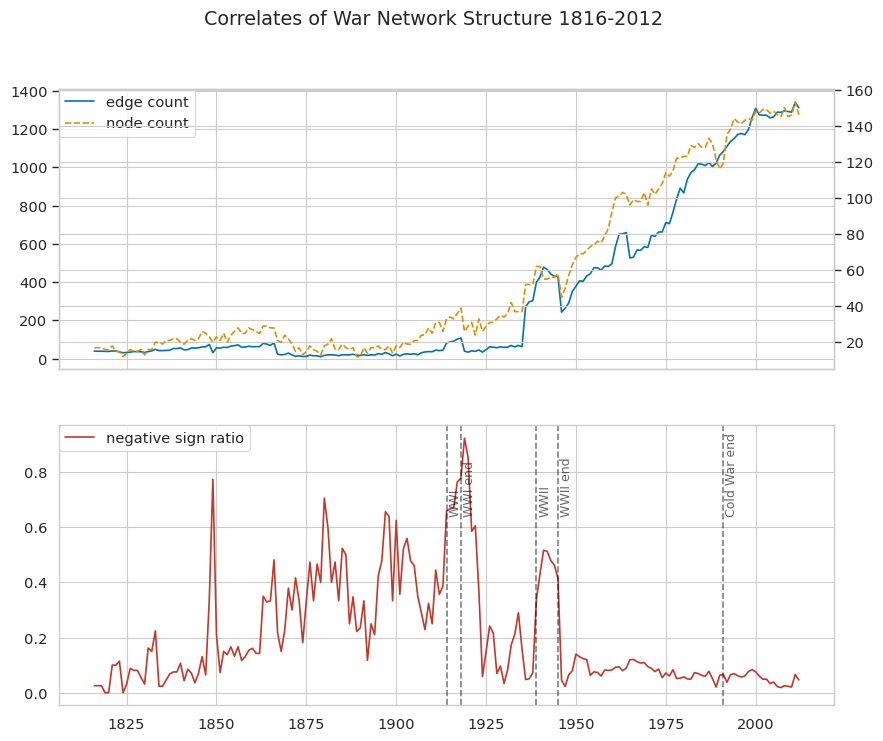

In [38]:
# visualise CoW descriptive statistics
years = sorted(cow_graphs.keys())
nodes = [cow_graphs[y].number_of_nodes() for y in years]
edges = [cow_graphs[y].number_of_edges() for y in years]
p_neg = [sum(1 for u,v,d in cow_graphs[y].edges(data=True) 
             if d['sign']==-1) / cow_graphs[y].number_of_edges() 
         for y in years]

fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax[0].plot(years, edges, label='edge count', color = colours[0])
axb = ax[0].twinx()
axb.plot(years, nodes, linestyle = '--', label='node count', color = colours[1])

lines1, labels1 = ax[0].get_legend_handles_labels()
lines2, labels2 = axb.get_legend_handles_labels()
ax[0].legend(lines1 + lines2, labels1 + labels2, loc='upper left', bbox_to_anchor=(0, 1), borderaxespad=0)

ax[1].plot(years, p_neg, label='negative sign ratio', color = '#c0392b')
ax[1].legend(loc='upper left', bbox_to_anchor=(0, 1), borderaxespad=0)

key_years = {1914: 'WWI', 1918: 'WWI end', 
             1939: 'WWII', 1945: 'WWII end', 1991: 'Cold War end'}

for year, label in key_years.items():
    ax[1].axvline(x=year, color='black', linestyle='--', alpha=0.5)
    ax[1].text(year+0.5, 0.65, label, rotation=90, fontsize=9, color='black', alpha=0.6)

fig.suptitle('Correlates of War Network Structure 1816-2012')
# plt.savefig('/home/student036/Desktop/Research-Phase/Project_Template/images/cowstats.png', bbox_inches='tight', dpi = 250)

Text(0.5, 0.98, 'Correlates of War Network Structure 1816-2012 (hostility level = 4)')

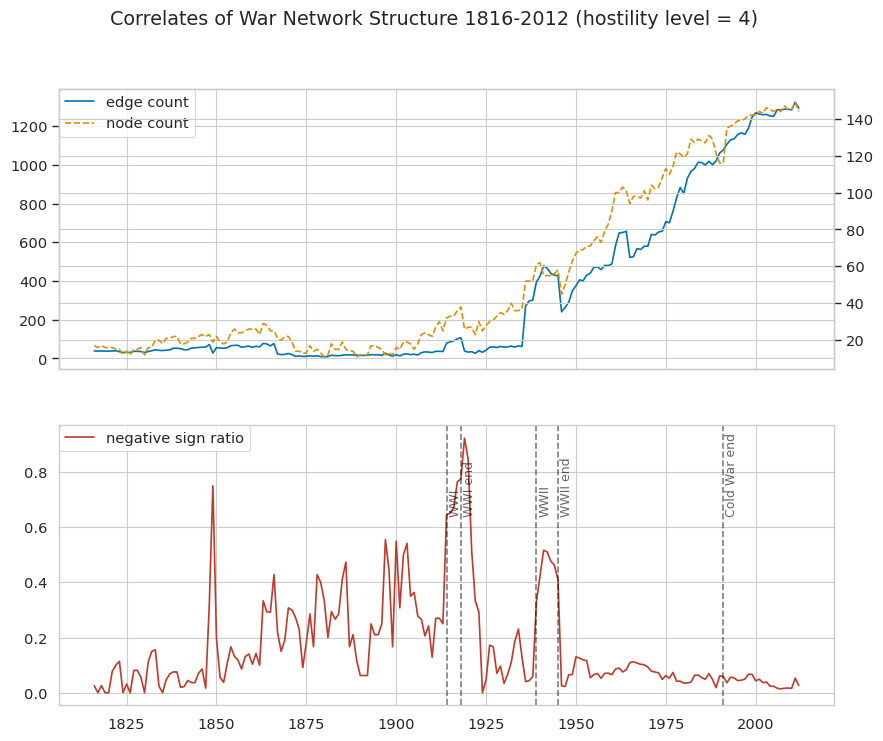

In [39]:
# visualise CoW descriptive statistics for threshold=4
years = sorted(cow_graphs_4.keys())
nodes = [cow_graphs_4[y].number_of_nodes() for y in years]
edges = [cow_graphs_4[y].number_of_edges() for y in years]
p_neg = [sum(1 for u,v,d in cow_graphs_4[y].edges(data=True) 
             if d['sign']==-1) / cow_graphs_4[y].number_of_edges() 
         for y in years]

fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax[0].plot(years, edges, label='edge count', color = colours[0])
axb = ax[0].twinx()
axb.plot(years, nodes, linestyle = '--', label='node count', color = colours[1])

lines1, labels1 = ax[0].get_legend_handles_labels()
lines2, labels2 = axb.get_legend_handles_labels()
ax[0].legend(lines1 + lines2, labels1 + labels2, loc='upper left', bbox_to_anchor=(0, 1), borderaxespad=0)

ax[1].plot(years, p_neg, label='negative sign ratio', color = '#c0392b')
ax[1].legend(loc='upper left', bbox_to_anchor=(0, 1), borderaxespad=0)

key_years = {1914: 'WWI', 1918: 'WWI end', 
             1939: 'WWII', 1945: 'WWII end', 1991: 'Cold War end'}

for year, label in key_years.items():
    ax[1].axvline(x=year, color='black', linestyle='--', alpha=0.5)
    ax[1].text(year+0.5, 0.65, label, rotation=90, fontsize=9, color='black', alpha=0.6)

fig.suptitle('Correlates of War Network Structure 1816-2012 (hostility level = 4)')
# plt.savefig('/home/student036/Desktop/Research-Phase/Project_Template/images/cowstats4.png', bbox_inches='tight', dpi = 250)

## Balance Comparison

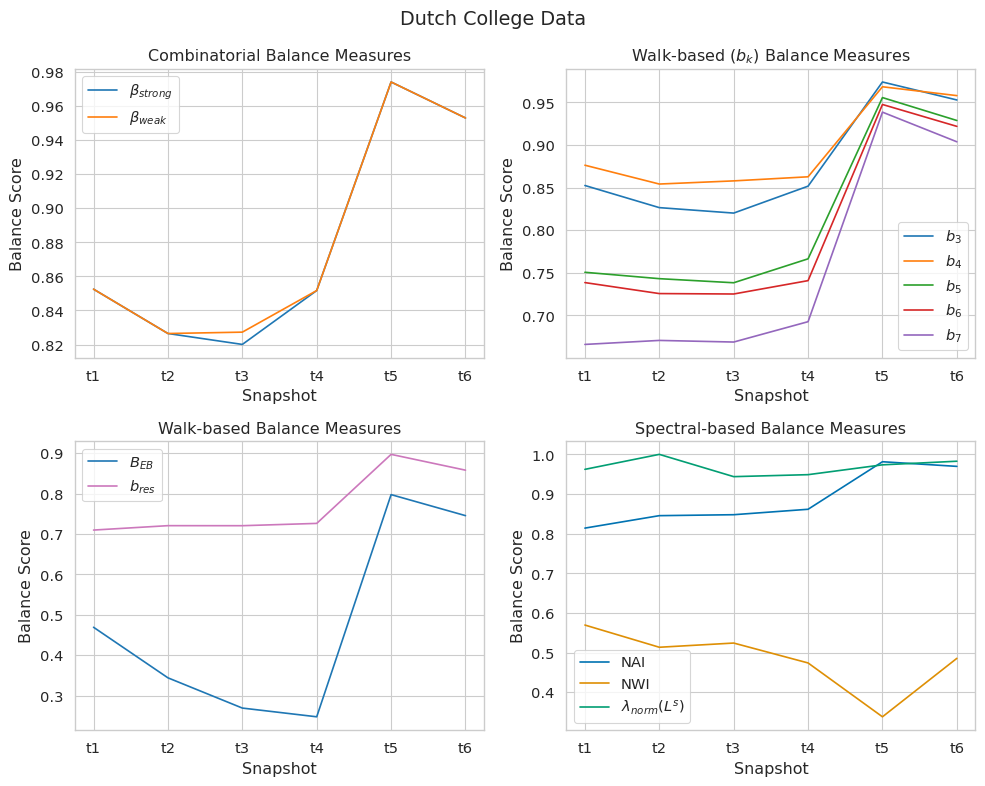

In [40]:
plot_measures(dutch_measures_df, 'Dutch College Data', 7, save_path=False)

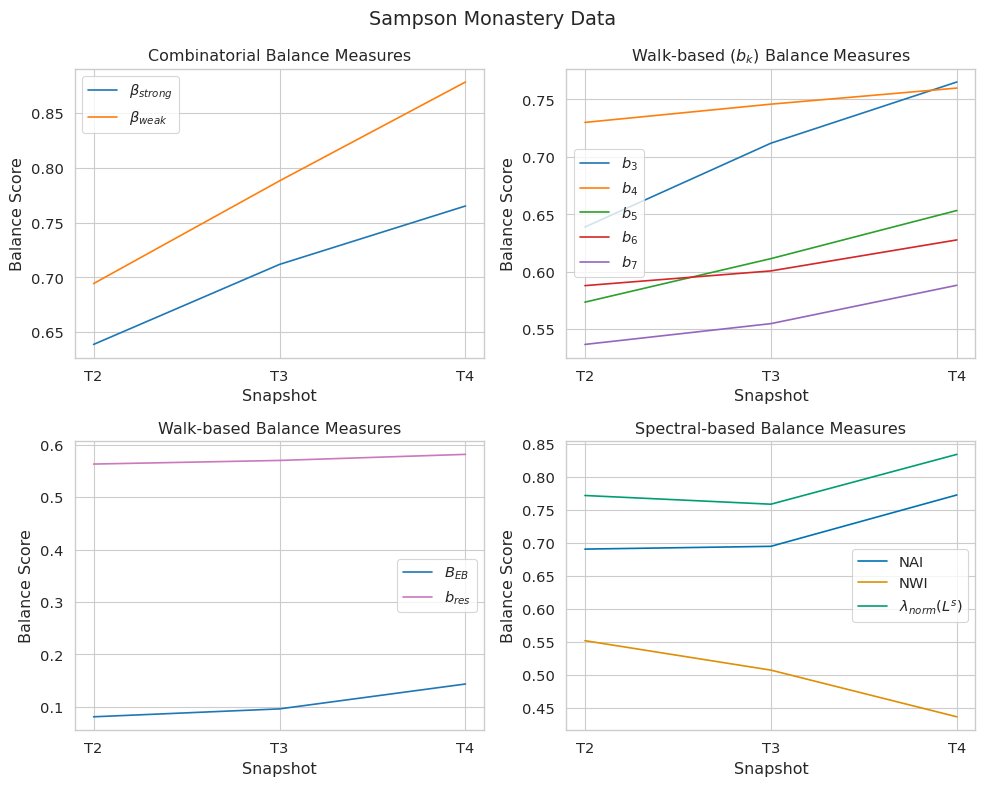

In [41]:
plot_measures(samps_measures_df, 'Sampson Monastery Data', 7, save_path=False)

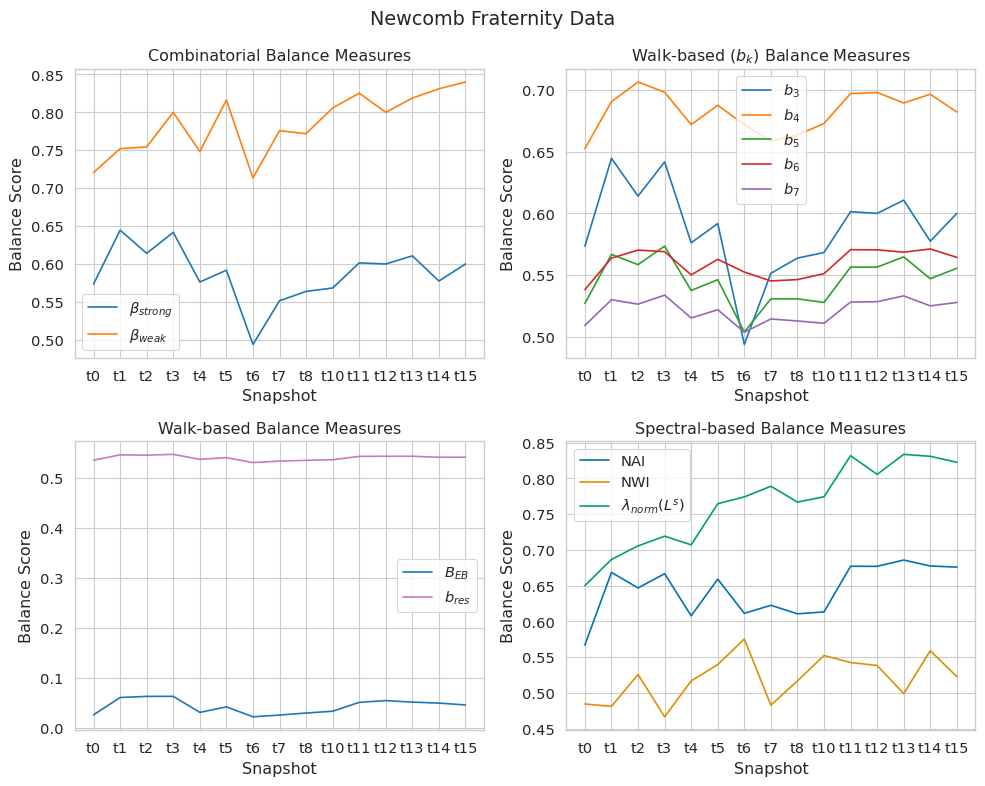

In [42]:
plot_measures(frat_measures_df, 'Newcomb Fraternity Data', 7, save_path=False)

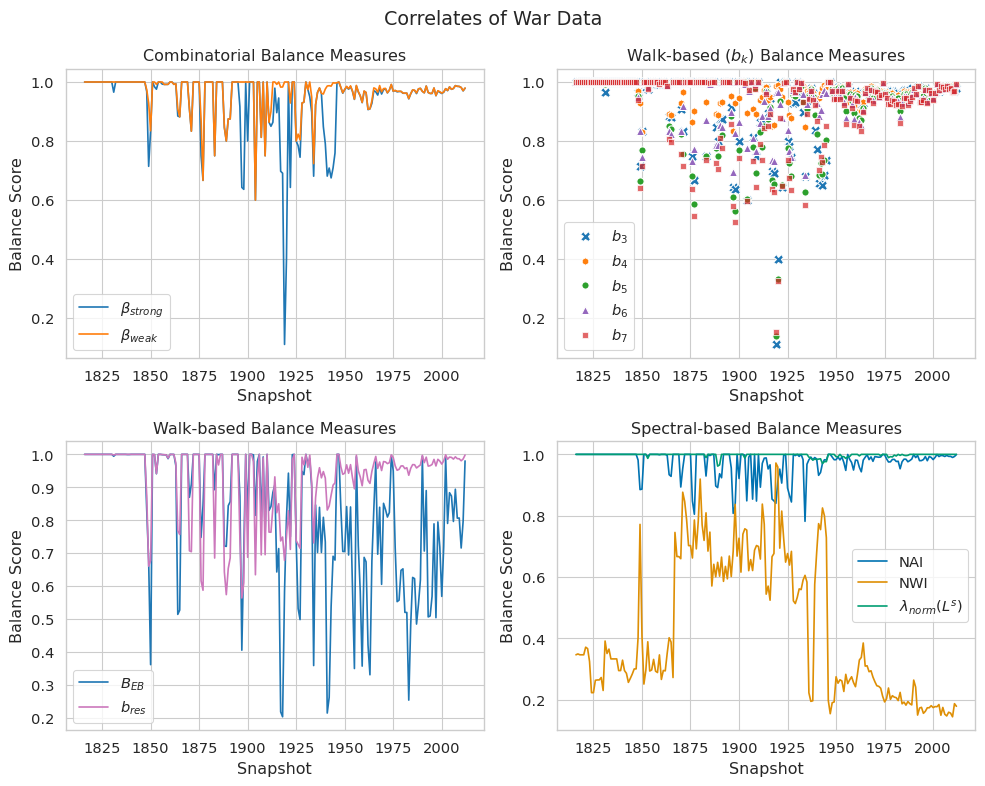

In [43]:
plot_measures(cow_measures_df, 'Correlates of War Data', 7, is_cow = True, save_path=False)

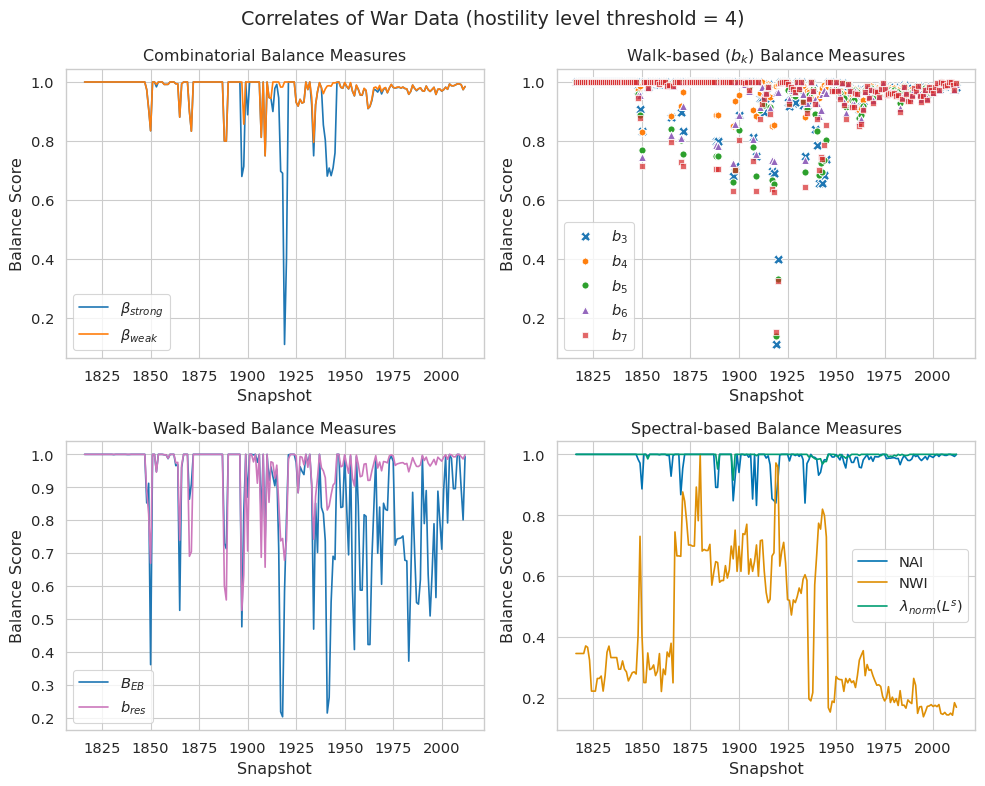

In [44]:
plot_measures(cow_measures_df_4, 'Correlates of War Data (hostility level threshold = 4)', 7, is_cow = True, save_path=False)

## Correlation Map

In [53]:
# list columns and dataframes to build correlation matrix for
corr_cols = ['β_strong', 'β_weak', 
             'b_3', 'b_4', 'b_5', 'b_6', 'b_7',
             'B_EB', 'b_res',
            'NAI', 'NWI', 'L_norm']


datasets = [
    (dutch_measures_df, 'Dutch College'),
    (samps_measures_df, 'Sampson Monastery'),
    (frat_measures_df, 'Newcomb Fraternity'),
    (cow_measures_df, 'Correlates of War'),
    (cow_measures_df_4, 'Correlates of War (hostility level = 4)')
]

names = ['dutch', 'sampson', 'frat', 'cow', 'cow_4']

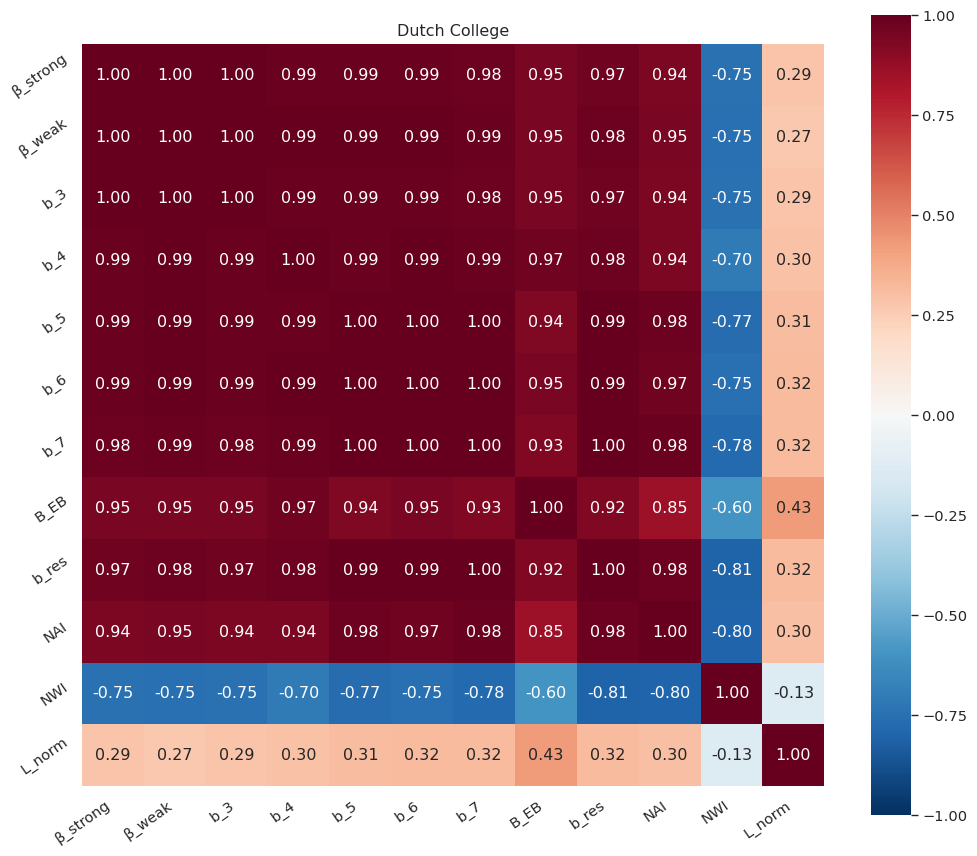

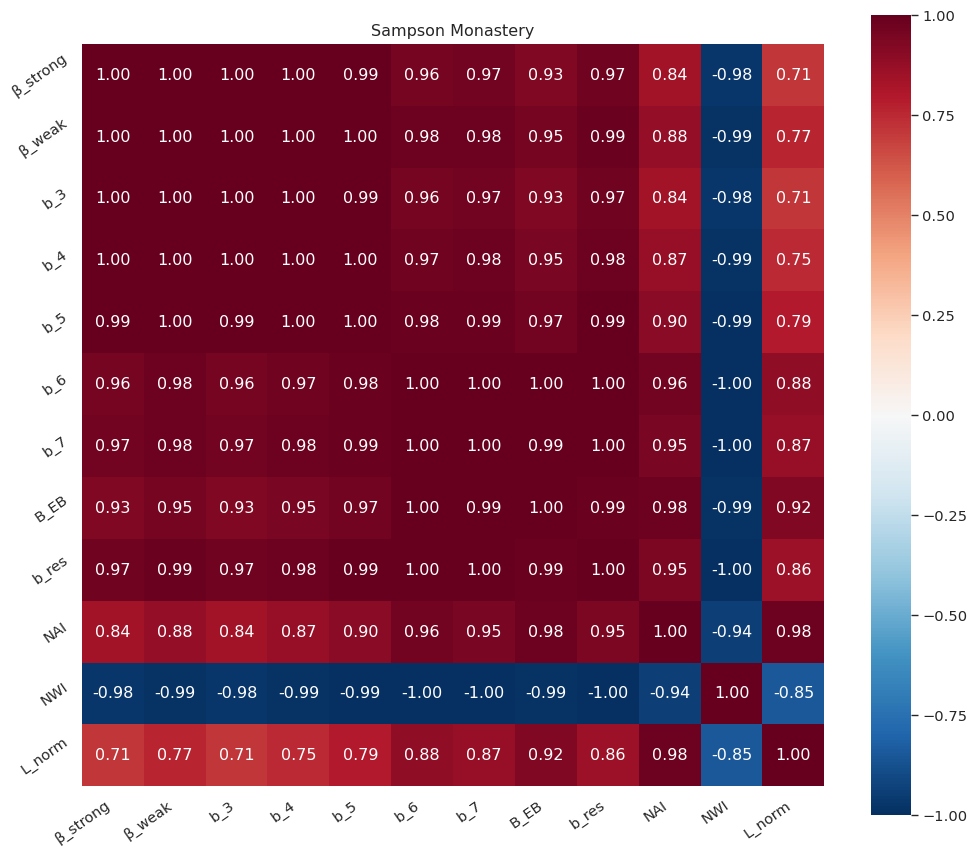

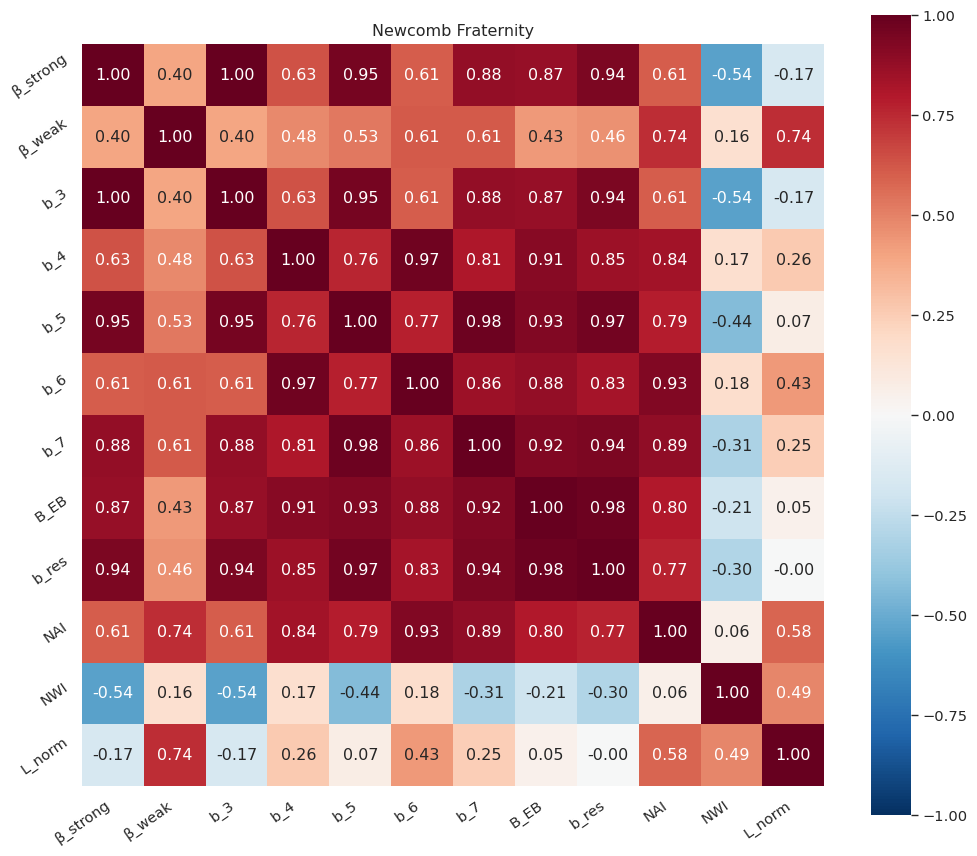

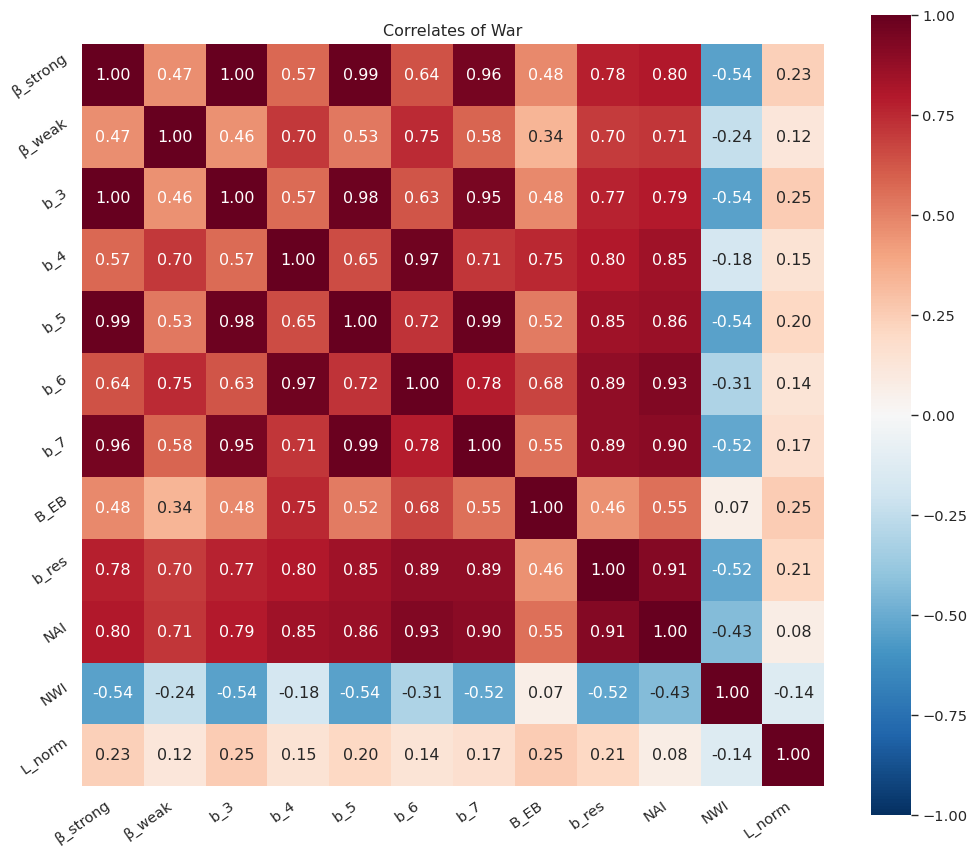

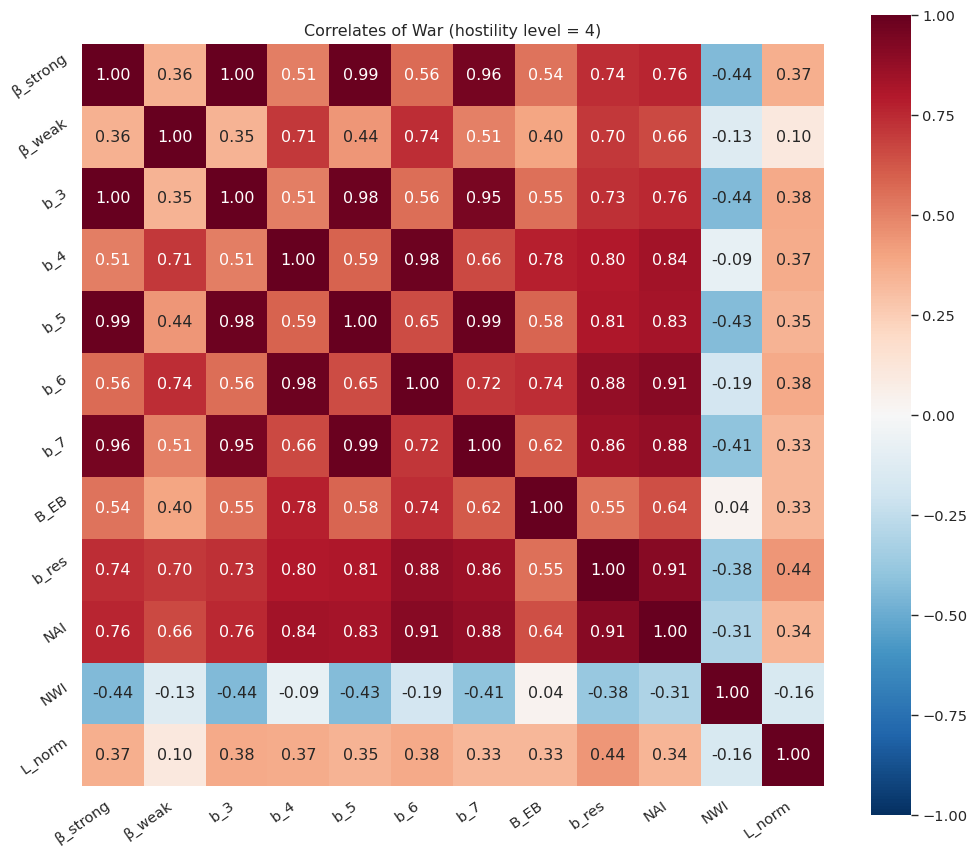

In [46]:
# create correlation matrices
for name, (df, label) in zip(names,datasets):
    fig, ax = plt.subplots(1, 1, figsize = (10, 10))
    corr_map = df[corr_cols].corr()
    sns.heatmap(corr_map, ax=ax, annot=True, fmt='.2f', cmap='RdBu_r', square = True, 
                vmin=-1, vmax=1, cbar_kws={'shrink': 0.8, 'aspect': 20})
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=35, ha='right')
    ax.set_title(label)
    plt.tight_layout(pad=0)
    # plt.savefig(f'/home/student036/Desktop/Research-Phase/Project_Template/images/{name}_heatmap.png', dpi=250, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    # print(f'Saved {name}')

## Full Synthetic Graph Correlation Map

In [47]:
graph_subset = synthetic_graphs_df

walk_cols = [c for c in graph_subset if c.startswith('b_') and c[2:].isdigit()]

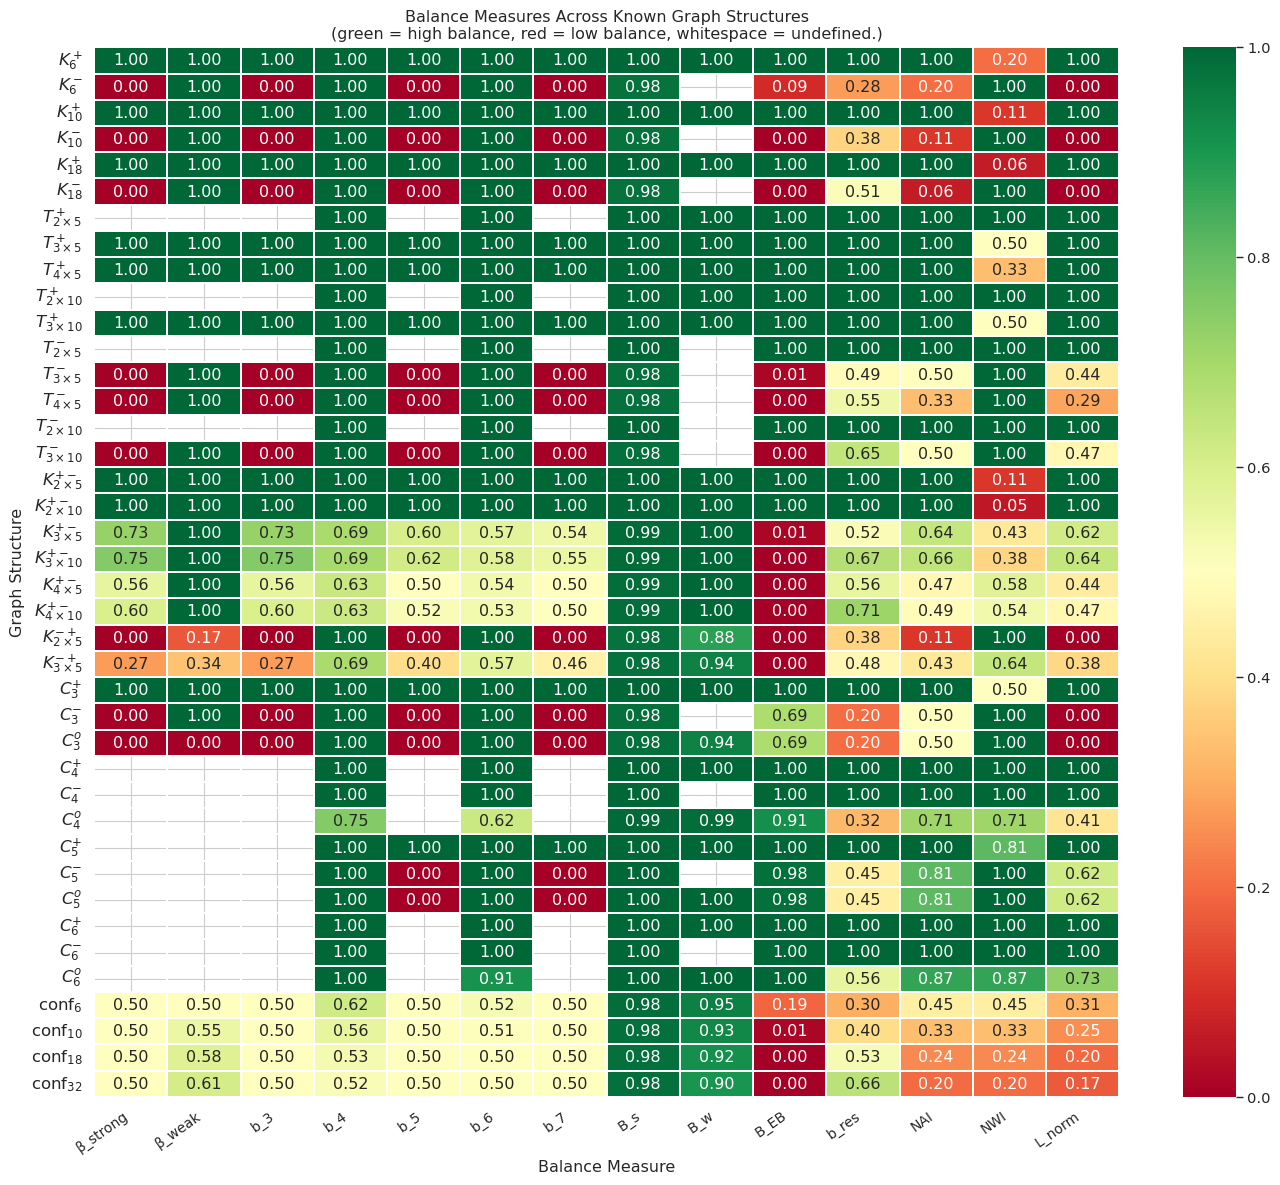

In [48]:
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(graph_subset, cmap='RdYlGn', annot=True, fmt='.2f',
            linewidths=0.3, 
            ax=ax, vmin=0, vmax=1)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), fontsize = 12)
ax.set_title('Balance Measures Across Known Graph Structures\n(green = high balance, red = low balance, whitespace = undefined.)')
ax.set_xlabel('Balance Measure')
ax.set_ylabel('Graph Structure')
plt.tight_layout()
# plt.savefig('/home/student036/Desktop/Research-Phase/Project_Template/images/syncorr.png', bbox_inches ='tight', dpi=250)

## NAI-NWI Scatter Plot

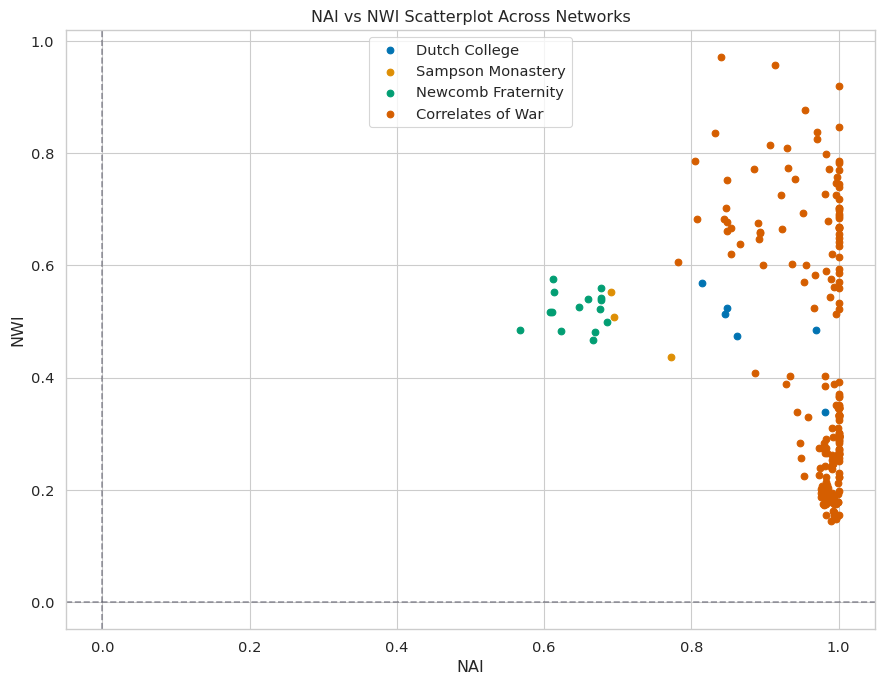

In [54]:
# plot NAI-NWI scatter plot
fig, ax = plt.subplots(1, 1, figsize=(9, 7))
for i, (df, name) in enumerate(datasets):
    ax.scatter(df['NAI'], df['NWI'], color = colours[i], label=name)
ax.set_xlabel('NAI')
ax.set_ylabel('NWI')
ax.set_title('NAI vs NWI Scatterplot Across Networks')
ax.legend()
ax.axhline(y=0, color='#3d3d4e', linestyle='--', alpha=0.5)
ax.axvline(x=0, color='#3d3d4e', linestyle='--', alpha=0.5)
plt.tight_layout()
# plt.savefig('/home/student036/Desktop/Research-Phase/Project_Template/images/scatter.png', bbox_inches ='tight', dpi=250)
plt.show()

## Sign Proportion Graph

In [50]:
def plot_sign_proportion(df, name):
    '''create 2x2 grid of sign proportion experiment for each network'''
    fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=False)
    fig.suptitle(f'{name} — Sign Proportion Experiment', fontsize=13)
    
    # Group by p_neg and compute mean and std across snapshots
    grouped = df.groupby('p_neg')
    p_neg_vals = sorted(df['p_neg'].unique())
    
    def get_mean_std(col):
        means = grouped[col].mean()
        stds = grouped[col].std()
        return means.values, stds.values
    
    def plot_with_band(ax, col, label, colour):
        means, stds = get_mean_std(col)
        ax.plot(p_neg_vals, means, label=label, color=colour)
        ax.fill_between(p_neg_vals, means - stds, means + stds, 
                       alpha=0.2, color=colour)
    
    # Panel 1 — Combinatorial
    plot_with_band(axes[0,0], 'β_strong', 'β_strong', 'blue')
    plot_with_band(axes[0,0], 'β_weak', 'β_weak', 'orange')
    axes[0,0].set_ylabel('Measure score')
    axes[0,0].set_title('Combinatorial')
    axes[0,0].legend(fontsize=8)
    axes[0,0].set_xlabel('Proportion of negative edges (p_neg)')
    
    # Panel 2 — Functional
    plot_with_band(axes[0,1], 'B_EB', 'B_EB', 'blue')
    plot_with_band(axes[0,1], 'b_res', 'b_res', 'purple')
    axes[0,1].set_ylabel('Measure score')
    axes[0,1].set_title('Walk-based Matrix Functional')
    axes[0,1].legend(fontsize=8)
    axes[0,1].set_xlabel('Proportion of negative edges (p_neg)')
    
    # Panel 3— bk
    colours_bk = colours[:7]
    for col, colour in zip(['b_3','b_4','b_5','b_6','b_7'], colours_bk):
        plot_with_band(axes[1,0], col, col, colour)
    axes[1,0].set_ylabel('Measure score')
    axes[1,0].set_title(r'Walk-based $b_k$ Measures')
    axes[1,0].legend(fontsize=8)
    axes[1,0].set_xlabel('Proportion of negative edges (p_neg)')
    
    # Panel 4 — Spectral
    plot_with_band(axes[1,1], 'NAI', 'NAI', 'blue')
    plot_with_band(axes[1,1], 'NWI', 'NWI', 'orange')
    plot_with_band(axes[1,1], 'L_norm', r'$\lambda_{norm}(L^s)$', 'green')
    axes[1,1].set_ylabel('Measure score')
    axes[1,1].set_title('Spectral')
    axes[1,1].legend(fontsize=8, loc='upper left')

    
    axes[1,1].set_xlabel('Proportion of negative edges (p_neg)')
    plt.tight_layout()

    label = name.lower().split()[0]
    print(f'Saved {label}')
    # plt.savefig(f'/home/student036/Desktop/Research-Phase/Project_Template/images/{label}_sign_prop.png', dpi=250, bbox_inches='tight')
    
    plt.show()
    plt.close()

Saved dutch


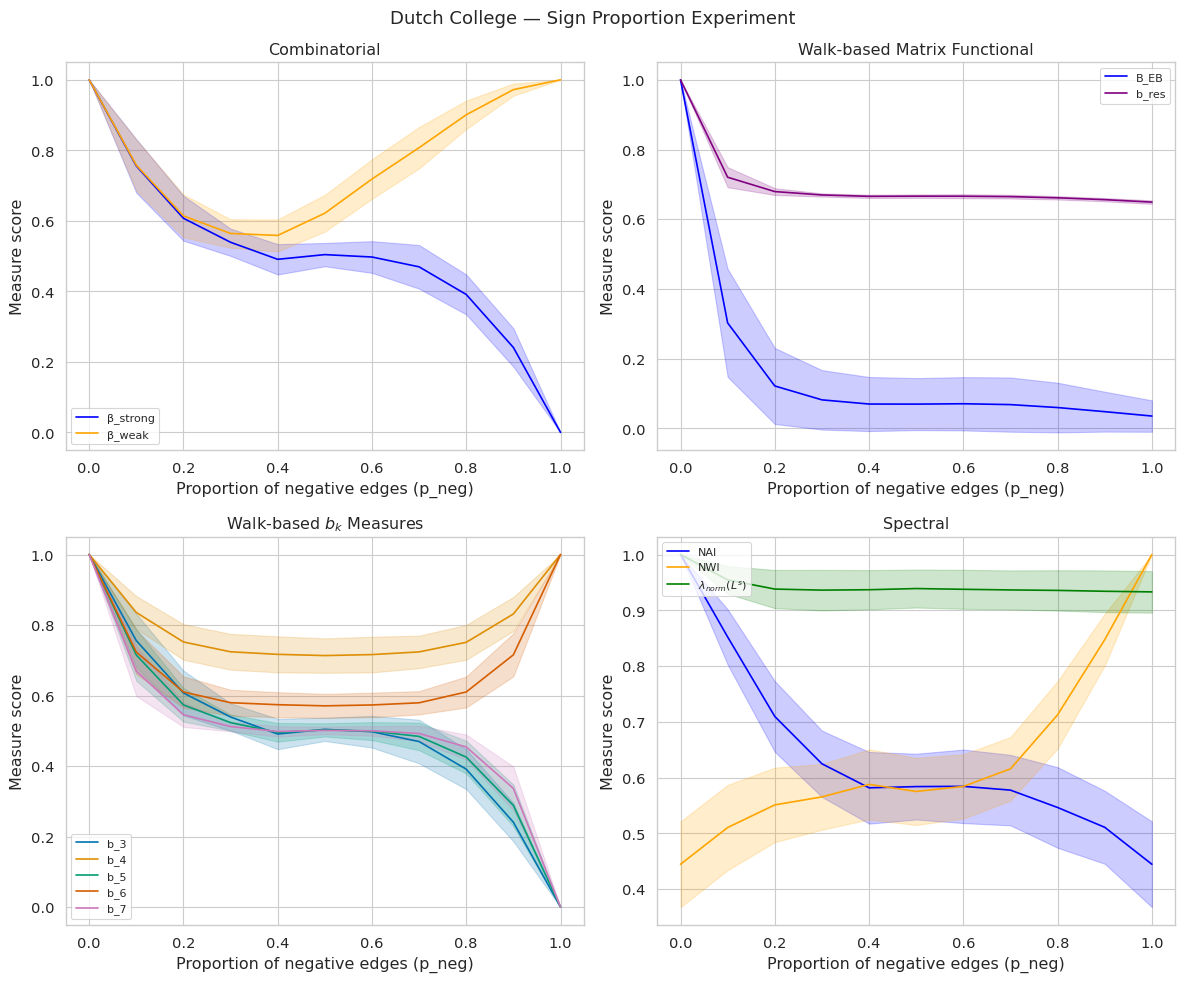

Saved sampson


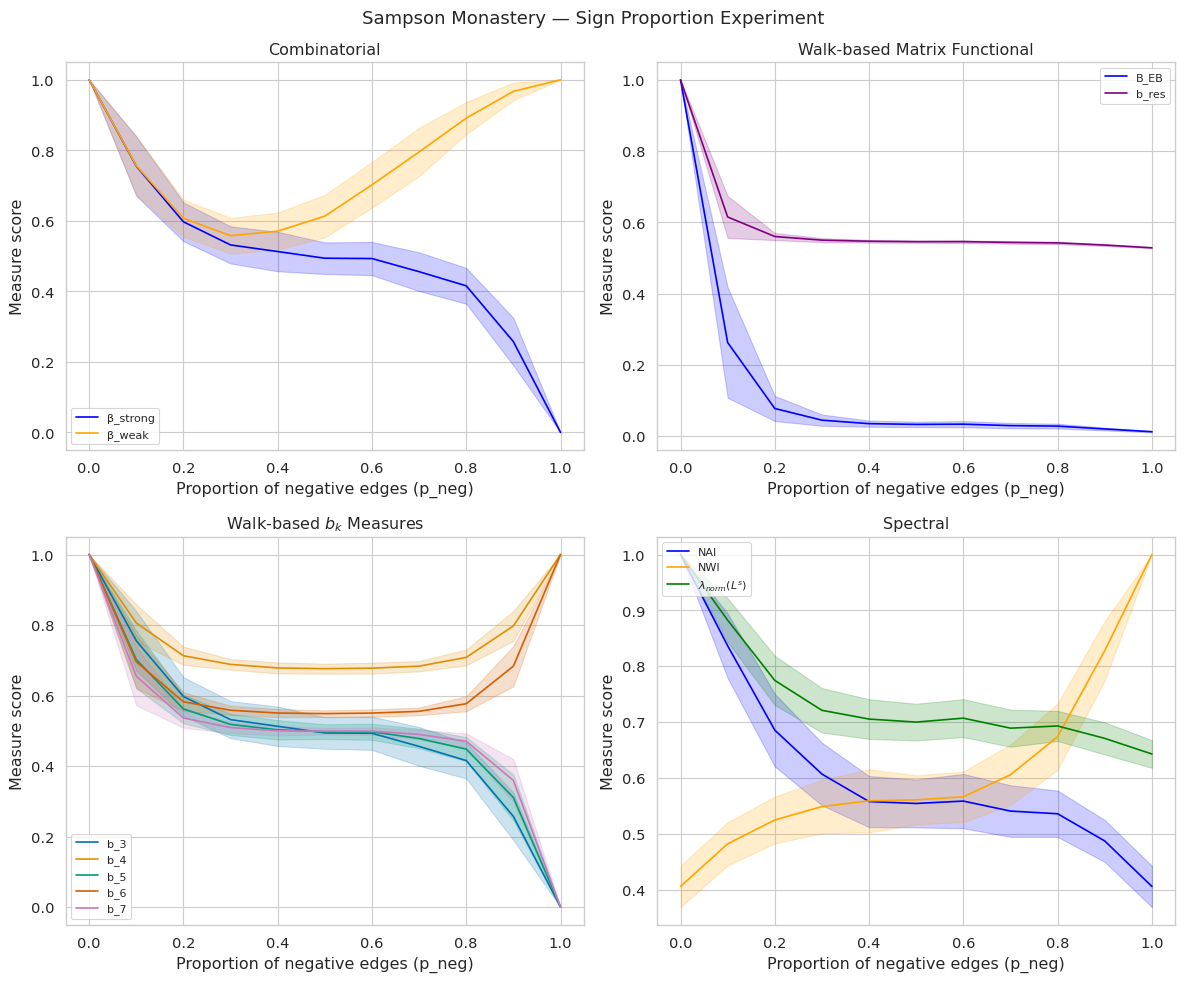

Saved newcomb


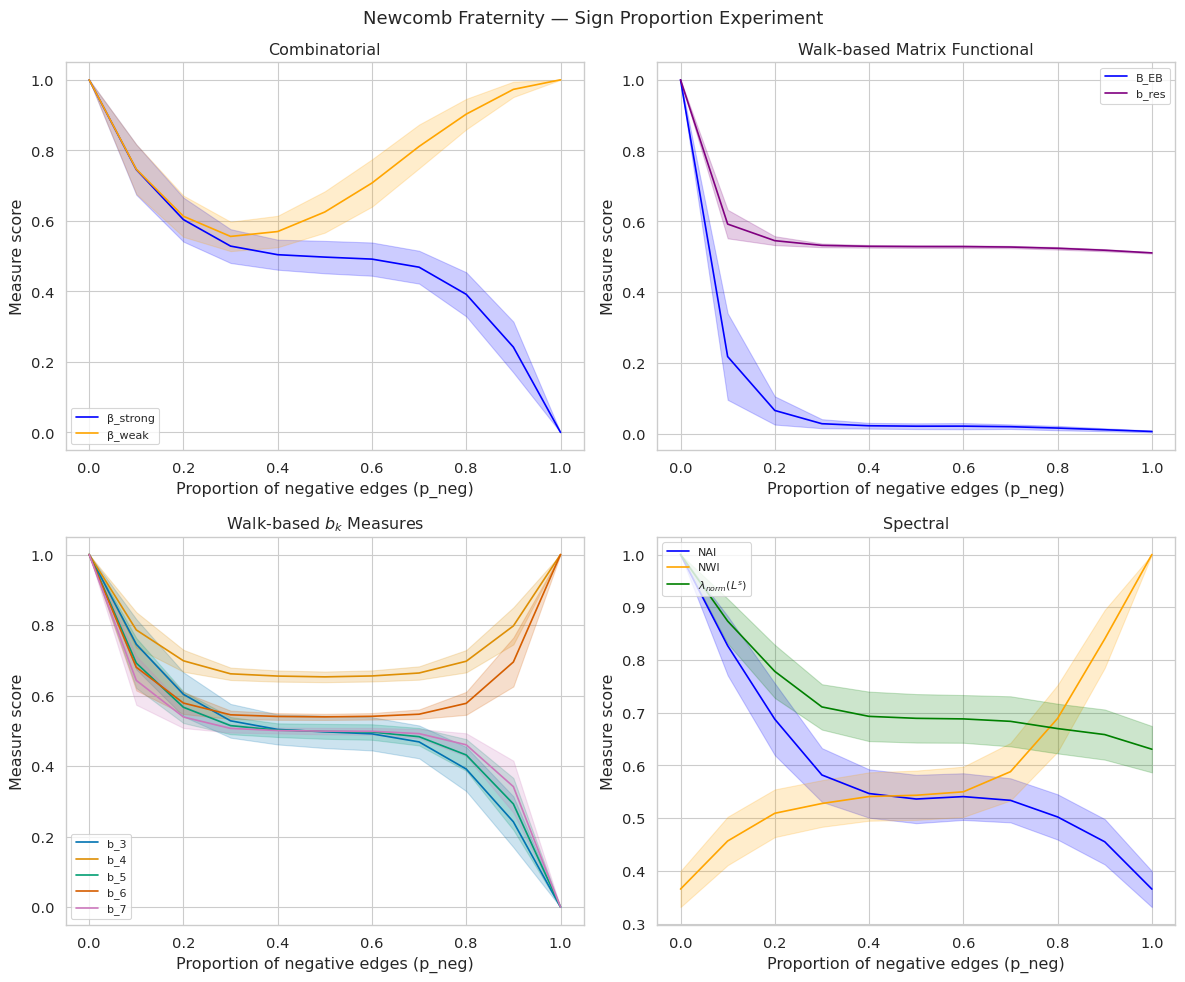

Saved correlates


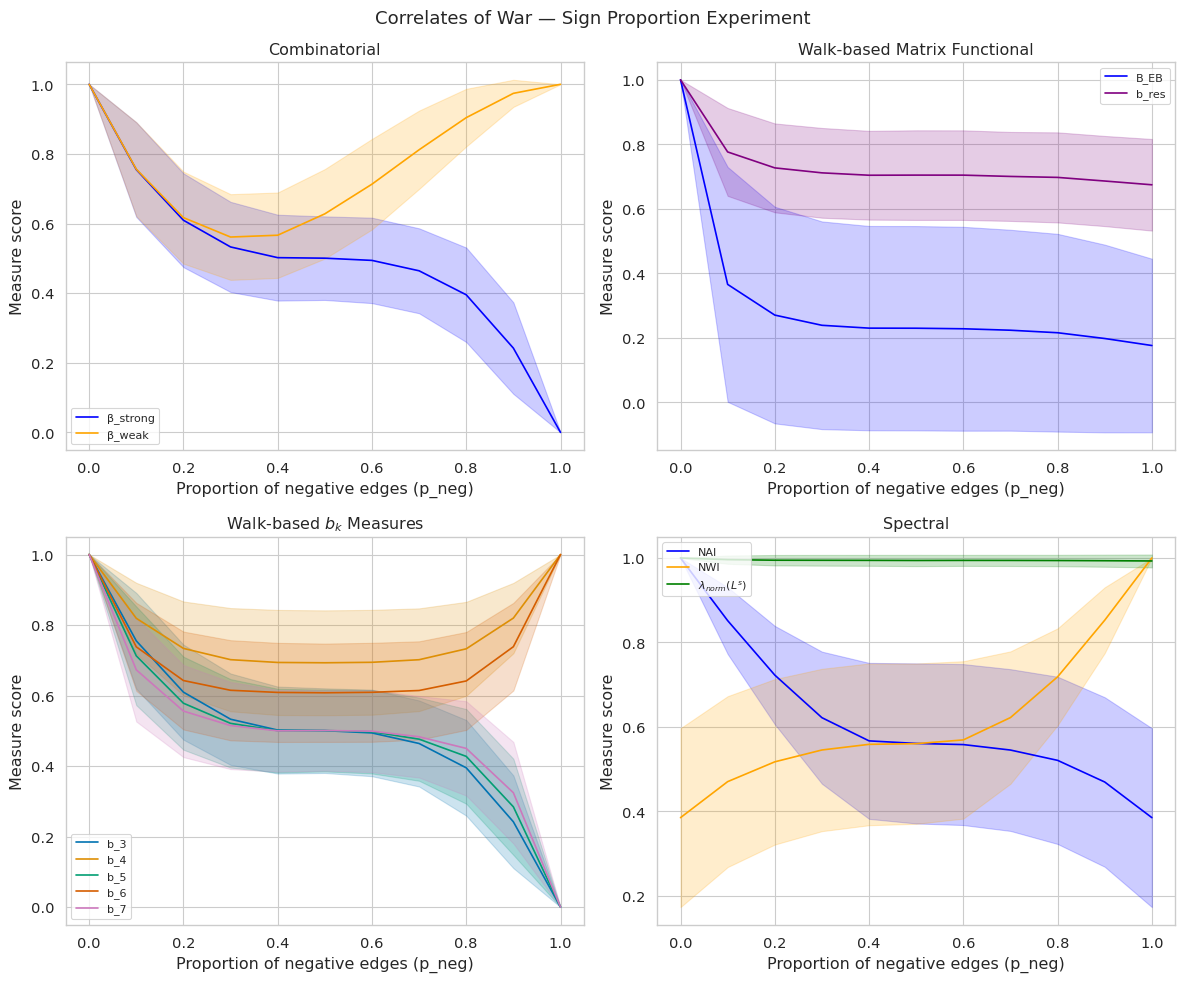

In [51]:
sign_dfs = [
    (perturb_dutch, 'Dutch College'),
     (perturb_sampson, 'Sampson Monastery'),
    (perturb_frat, 'Newcomb Fraternity'),
    (perturb_cow, 'Correlates of War')
]
for df, name in sign_dfs:
    df_new = df.reset_index()
    plot_sign_proportion(df_new, name)

# NWI Testing

In [ ]:
# empirical test of NWI values on different graph structures
results = []

for k in range(2, 16):
    for m in [5, 10, 20, 50, 100]:
        
#  All-positive signing 
        G_pos = construct_complete_graph(
            groupsizelist=[m] * k,
            kind='all_positive'          
        )
        mats_pos = compute_matrices(G_pos)
        A_pos     = mats_pos['signed_adj']
        A_abs     = mats_pos['abs_adj']   

        eigs_pos       = np.sort(sl.eigvalsh(A_pos))  
        lambda_max_abs = sl.eigvalsh(A_abs)[-1]         
        lambda_min_pos = eigs_pos[0]                   
        abs_lmin_pos   = abs(lambda_min_pos)
        rho_pos        = abs_lmin_pos / lambda_max_abs
       
        NWI_pos = NWI(G_pos)

        results.append({
            'k'               : k,
            'm'               : m,
            'm (predicted)'   : m,         
            'n'               : k * m,
            'signing'         : 'pos',
            'lambda_max(|A|)' : round(lambda_max_abs, 4),
            'lambda_min(A+)'  : round(lambda_min_pos, 4),
            '|lambda_min|'    : round(abs_lmin_pos, 4),
            'ratio'             : round(rho_pos, 4),
            'NWI'         : round(NWI_pos, 4)
        })
#########################################################################################################################################
#######################################################################################################################################
        
        # --- All-negative signing ---
        G_neg = construct_complete_graph(
            groupsizelist=[m] * k,
            kind = 'all_negative'         
        )
        mats_neg = compute_matrices(G_neg)
        A_neg = mats_neg['signed_adj']

        eigs_neg       = np.sort(sl.eigvalsh(A_neg))
        lambda_min_neg = eigs_neg[0]
        abs_lmin_neg   = abs(lambda_min_neg)
        rho_neg        = abs_lmin_neg / lambda_max_abs
        NWI_neg = NWI(G_neg)

        results.append({
            'k'               : k,
            'm'               : m,
            'n'               : k * m,
            'signing'         : 'neg',
            'lambda_max(|A|)' : round(lambda_max_abs, 4),
            'lambda_min(A-)'  : round(lambda_min_neg, 4),
            '|lambda_min|'    : round(abs_lmin_neg, 4),
            'm (predicted)'   : m * (k - 1),  
            'ratio'             : round(rho_neg, 4),
            'NWI'         : round(NWI_neg, 4)
        })

#########################################################################################################################################
#######################################################################################################################################
 #negated balance (antibalance only for k=2) signing 
        G_anti = construct_complete_graph(
            groupsizelist=[m] * k,
            kind = 'negated_balance'         
        )
        mats_anti = compute_matrices(G_anti)
        A_anti = mats_anti['signed_adj']


        eigs_anti       = np.sort(sl.eigvalsh(A_anti))
        lambda_min_anti = eigs_anti[0]
        abs_lmin_anti   = abs(lambda_min_anti)
        rho_anti        = abs_lmin_anti / lambda_max_abs

        NWI_anti = NWI(G_anti)

        results.append({
            'k'               : k,
            'n'               : k * m,
            'm'               : m,
            'm (predicted)'   : m * (k - 1),  
            'signing'         : 'anti',
            'lambda_max(|A|)' : round(lambda_max_abs, 4),
            'lambda_min(A)'  : round(lambda_min_anti, 4),
            '|lambda_min|'    : round(abs_lmin_anti, 4),
            'ratio'             : round(rho_anti, 4),
            'NWI'         : round(NWI_anti, 4)
        })

#########################################################################################################################################
#######################################################################################################################################

          # Bipartite signing
        G_bip = construct_complete_graph(
            groupsizelist=[m] * k,
            kind = 'bipartite'      
        )
        mats_bip = compute_matrices(G_bip)
        A_bip = mats_bip['signed_adj']


        eigs_bip       = np.sort(sl.eigvalsh(A_bip))
        lambda_min_bip = eigs_bip[0]
        abs_lmin_bip   = abs(lambda_min_bip)
        rho_bip        = abs_lmin_bip / lambda_max_abs
        # one_minus_rho_anti = 1 - rho_anti
        NWI_bip = NWI(G_bip)

        results.append({
            'k'               : k,
            'n'               : k * m,
            'm'               : m,
            'm (predicted)'   : m * (k - 1),  
            'signing'         : 'bip',
            'lambda_max(|A|)' : round(lambda_max_abs, 4),
            'lambda_min(A)'  : round(lambda_min_bip, 4),
            '|lambda_min|'    : round(abs_lmin_bip, 4),
            'ratio'             : round(rho_bip, 4),
            'NWI'         : round(NWI_bip, 4)
        })

test_df = pd.DataFrame(results)


#########################################################################################################################################
#######################################################################################################################################
# --- Print separated by signing for readability ---
print(f'{"=" *5} ALL-POSITIVE SIGNING {"=" *5}')
print(test_df[test_df['signing'] == 'pos'][['k', 'n', 'm', 'm (predicted)','lambda_max(|A|)', 'lambda_min(A+)', '|lambda_min|','ratio','NWI']].to_string(index=False))

print(f'\n{"=" *5}ANTIBALANCED SIGNING {"=" *5}')
print(test_df[test_df['signing'] == 'neg'][['k', 'n', 'm', 'm (predicted)','lambda_max(|A|)','lambda_min(A-)','|lambda_min|','ratio','NWI']].to_string(index=False))

print(f'\n{"=" *5} NEGATED SIGNING (ANTIBALANCED for k=2) {"=" *5}')
print(test_df[test_df['signing'] == 'anti'][['k', 'n', 'm', 'm (predicted)','lambda_max(|A|)','lambda_min(A)','|lambda_min|','ratio','NWI']].to_string(index=False))

print(f'\n{"=" *5} REGULAR BALANCE SIGNING (STRONGLY BALANCED for k=2) {"=" *5}')
print(test_df[test_df['signing'] == 'bip'][['k', 'n', 'm', 'm (predicted)','lambda_max(|A|)','lambda_min(A)','|lambda_min|','ratio','NWI']].to_string(index=False))